# YOLO11n Fine-tuning + n/s/m/Fine-tuned 전체 지표 비교

## 0. 설치

In [ ]:

!pip install -q -U ultralytics
!pip install -q "transformers==4.51.0" "accelerate==1.8.1" "timm==0.8.13.dev0" "lapx>=0.5.2"
!pip install -q --no-deps git+https://github.com/WildChlamydia/MiVOLO.git


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.3/365.3 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 67.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub

## 1. Import + Google Drive + GPU 확인

In [ ]:

import os
import sys
import time
import shutil
import random
import zipfile
import warnings
from pathlib import Path

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    mean_absolute_error,
)

from ultralytics import YOLO

from transformers import (
    AutoConfig,
    AutoModelForImageClassification,
    AutoImageProcessor,
)

from google.colab import drive
drive.mount("/content/drive")

warnings.filterwarnings("ignore")

DEVICE = 0 if torch.cuda.is_available() else "cpu"
TORCH_DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA   :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "GPU가 활성화되지 않았습니다.\n"
        "Colab 메뉴에서 런타임 → 런타임 유형 변경 → T4 GPU로 변경한 뒤 다시 실행하세요."
    )


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Python : 3.12.13
PyTorch: 2.11.0+cu128
CUDA   : True
GPU    : Tesla T4



## 2. 경로 설정 + ZIP 자동 해제



In [ ]:
# A. 공통 Base 경로

BASE_DIR = Path(
    "/content/drive/MyDrive/cabin_guard_eval"
)

# B. 기존 Fine-tuning Person 데이터

PERSON_DATASET_ROOT = (
    BASE_DIR / "person_dataset"
)

PERSON_SPLITS = {
    "train": "train",
    "val": "valid",
}

# 원본 person dataset:
# 0 = young
# 1 = old
#
# YOLO에서는 둘 다 person(0)
PERSON_CLASS_MAP = {
    0: 0,
    1: 0,
}

# C. 추가 UTKFace Fine-tuning 100장

UTK_FT_ZIP = (
    BASE_DIR / "UTKFace_YOLO11_person_100.zip"
)

UTK_FT_ROOT = (
    BASE_DIR / "UTKFace_YOLO11_person_100"
)

if UTK_FT_ROOT.exists():
    print(
        "[UTK Fine-tune] 이미 압축 해제됨:",
        UTK_FT_ROOT,
    )
else:
    if not UTK_FT_ZIP.exists():
        raise FileNotFoundError(
            "UTKFace Fine-tuning ZIP 파일이 없습니다:\n"
            f"{UTK_FT_ZIP}\n\n"
            "UTKFace_YOLO11_person_100.zip을 "
            "MyDrive/cabin_guard_eval/에 업로드하세요."
        )

    print(
        "[UTK Fine-tune] ZIP 압축 해제 중..."
    )

    with zipfile.ZipFile(
        UTK_FT_ZIP,
        "r",
    ) as z:
        z.extractall(BASE_DIR)

    if not UTK_FT_ROOT.exists():
        raise RuntimeError(
            "ZIP은 풀렸지만 "
            "UTKFace_YOLO11_person_100 폴더를 찾지 못했습니다."
        )

    print(
        "[UTK Fine-tune] 압축 해제 완료:",
        UTK_FT_ROOT,
    )

UTK_FT_SPLITS = {
    "train": "train",
    "val": "val",
}


UTK_FT_CLASS_MAP = {
    0: 0,
}

# D. Animal Fine-tuning 데이터

ANIMAL_ZIP = (
    BASE_DIR / "animal_100_yolo11.zip"
)

ANIMAL_DATASET_ROOT = (
    BASE_DIR / "animal_100_yolo11"
)

if ANIMAL_DATASET_ROOT.exists():
    print(
        "[Animal] 이미 압축 해제됨:",
        ANIMAL_DATASET_ROOT,
    )
else:
    if not ANIMAL_ZIP.exists():
        raise FileNotFoundError(
            f"동물 ZIP 파일이 없습니다:\n{ANIMAL_ZIP}"
        )

    print("[Animal] ZIP 압축 해제 중...")

    with zipfile.ZipFile(
        ANIMAL_ZIP,
        "r",
    ) as z:
        z.extractall(BASE_DIR)

    if not ANIMAL_DATASET_ROOT.exists():
        raise RuntimeError(
            "ZIP은 풀렸지만 animal_100_yolo11 폴더를 찾지 못했습니다."
        )

    print(
        "[Animal] 압축 해제 완료:",
        ANIMAL_DATASET_ROOT,
    )

ANIMAL_SPLITS = {
    "train": "train",
    "val": "val",
}

ANIMAL_CLASS_MAP = {
    0: 15,  # cat
    1: 16,  # dog
}

# E. 기존 Cabin 111장 Test

CABIN_ROOT = BASE_DIR

CABIN_IMAGE_DIR = (
    CABIN_ROOT / "images" / "val2"
)

CABIN_LABEL_DIR = (
    CABIN_ROOT / "labels" / "val2"
)

CABIN_AGE_CSV = (
    CABIN_ROOT / "labels.csv"
)

# F. 기존 UTKFace Balanced 100 Test 자동 탐색

UTK_CANDIDATES = [
    Path("/content/drive/MyDrive/UTKFace_balanced_100"),
    Path("/content/drive/MyDrive/UTKFace_balanced_100_yolo"),
    BASE_DIR / "UTKFace_balanced_100_yolo",
    Path(
        "/content/drive/MyDrive/"
        "UTKFace_balanced100_eval_bundle/"
        "UTKFace_balanced_100_yolo"
    ),
]

UTK_ROOT = None

for candidate in UTK_CANDIDATES:
    if (
        (candidate / "images" / "val").exists()
        and (candidate / "labels.csv").exists()
    ):
        UTK_ROOT = candidate
        break

# Test ZIP만 있는 경우 자동 해제
if UTK_ROOT is None:
    UTK_ZIP_CANDIDATES = [
        Path(
            "/content/drive/MyDrive/"
            "UTKFace_balanced_100_yolo.zip"
        ),
        BASE_DIR / "UTKFace_balanced_100_yolo.zip",
    ]

    for utk_zip in UTK_ZIP_CANDIDATES:
        if not utk_zip.exists():
            continue

        local_utk = Path(
            "/content/UTKFace_balanced_100_yolo"
        )

        if local_utk.exists():
            shutil.rmtree(local_utk)

        local_utk.mkdir(
            parents=True,
            exist_ok=True,
        )

        with zipfile.ZipFile(
            utk_zip,
            "r",
        ) as z:
            z.extractall(local_utk)

        if (
            (local_utk / "images" / "val").exists()
            and (local_utk / "labels.csv").exists()
        ):
            UTK_ROOT = local_utk
            break

        for child in local_utk.iterdir():
            if (
                child.is_dir()
                and (child / "images" / "val").exists()
                and (child / "labels.csv").exists()
            ):
                UTK_ROOT = child
                break

        if UTK_ROOT is not None:
            break

UTK_IMAGE_DIR = (
    UTK_ROOT / "images" / "val"
    if UTK_ROOT is not None
    else None
)

UTK_AGE_CSV = (
    UTK_ROOT / "labels.csv"
    if UTK_ROOT is not None
    else None
)

# G. 출력 / 작업 경로

MERGED_TRAIN_ROOT = Path(
    "/content/yolo11n_utk100_finetune_dataset"
)

WORK_ROOT = Path(
    "/content/drive/MyDrive/"
    "yolo11n_safe_finetune_utk100"
)

RUN_ROOT = (
    WORK_ROOT / "train_runs"
)

BEST_ROOT = (
    WORK_ROOT / "best_weight"
)

RESULT_ROOT = (
    WORK_ROOT / "colab_eval_results"
)

for p in [
    WORK_ROOT,
    RUN_ROOT,
    BEST_ROOT,
    RESULT_ROOT,
]:
    p.mkdir(
        parents=True,
        exist_ok=True,
    )

# H. 학습 설정

BASELINE_MODEL = "yolo11n.pt"

STAGE1_EPOCHS = 10
STAGE1_FREEZE = 10
STAGE1_LR = 0.0005

RUN_STAGE2 = False
STAGE2_EPOCHS = 5
STAGE2_LR = 0.0005

IMGSZ = 640
BATCH = 16
PATIENCE = 5
SEED = 42
WORKERS = 2

CONF = 0.25
AGE_THRESHOLD = 7.0

print()
print("=" * 72)
print("경로 / 설정")
print("=" * 72)
print("기존 Person     :", PERSON_DATASET_ROOT)
print("UTK FT 100      :", UTK_FT_ROOT)
print("Animal          :", ANIMAL_DATASET_ROOT)
print("Cabin Test      :", CABIN_IMAGE_DIR)
print("UTK Test        :", UTK_ROOT)
print("Output          :", WORK_ROOT)
print("DEVICE          :", DEVICE)
print(
    "Stage 1         : "
    "freeze=10, AdamW, lr0=0.0005, 10 epochs"
)


[UTK Fine-tune] 이미 압축 해제됨: /content/drive/MyDrive/cabin_guard_eval/UTKFace_YOLO11_person_100
[Animal] 이미 압축 해제됨: /content/drive/MyDrive/cabin_guard_eval/animal_100_yolo11

경로 / 설정
기존 Person     : /content/drive/MyDrive/cabin_guard_eval/person_dataset
UTK FT 100      : /content/drive/MyDrive/cabin_guard_eval/UTKFace_YOLO11_person_100
Animal          : /content/drive/MyDrive/cabin_guard_eval/animal_100_yolo11
Cabin Test      : /content/drive/MyDrive/cabin_guard_eval/images/val2
UTK Test        : /content/drive/MyDrive/UTKFace_balanced_100_yolo
Output          : /content/drive/MyDrive/yolo11n_safe_finetune_utk100
DEVICE          : 0
Stage 1         : freeze=10, AdamW, lr0=0.0005, 10 epochs



## 3. 학습 데이터 구조 검사



In [ ]:

required_train_paths = {
    # 기존 person
    "Person images/train":
        PERSON_DATASET_ROOT
        / "images"
        / PERSON_SPLITS["train"],

    "Person labels/train":
        PERSON_DATASET_ROOT
        / "labels"
        / PERSON_SPLITS["train"],

    "Person images/valid":
        PERSON_DATASET_ROOT
        / "images"
        / PERSON_SPLITS["val"],

    "Person labels/valid":
        PERSON_DATASET_ROOT
        / "labels"
        / PERSON_SPLITS["val"],

    # 새 UTK fine-tuning
    "UTK FT images/train":
        UTK_FT_ROOT
        / "images"
        / UTK_FT_SPLITS["train"],

    "UTK FT labels/train":
        UTK_FT_ROOT
        / "labels"
        / UTK_FT_SPLITS["train"],

    "UTK FT images/val":
        UTK_FT_ROOT
        / "images"
        / UTK_FT_SPLITS["val"],

    "UTK FT labels/val":
        UTK_FT_ROOT
        / "labels"
        / UTK_FT_SPLITS["val"],

    # animal
    "Animal images/train":
        ANIMAL_DATASET_ROOT
        / "images"
        / ANIMAL_SPLITS["train"],

    "Animal labels/train":
        ANIMAL_DATASET_ROOT
        / "labels"
        / ANIMAL_SPLITS["train"],

    "Animal images/val":
        ANIMAL_DATASET_ROOT
        / "images"
        / ANIMAL_SPLITS["val"],

    "Animal labels/val":
        ANIMAL_DATASET_ROOT
        / "labels"
        / ANIMAL_SPLITS["val"],
}

missing = []

for name, path in required_train_paths.items():
    if path.exists():
        print(f"[OK] {name}: {path}")
    else:
        print(f"[X]  {name}: {path}")
        missing.append(path)

if missing:
    raise FileNotFoundError(
        "학습 데이터 경로를 확인하세요."
    )

# UTK Fine-tuning 데이터 개수 확인
utk_ft_train_images = list(
    (UTK_FT_ROOT / "images" / "train").glob("*")
)

utk_ft_val_images = list(
    (UTK_FT_ROOT / "images" / "val").glob("*")
)

print()
print(
    "UTK Fine-tuning:",
    f"train={len(utk_ft_train_images)}, "
    f"val={len(utk_ft_val_images)}",
)

if (
    len(utk_ft_train_images) != 90
    or len(utk_ft_val_images) != 10
):
    print(
        "[주의] 예상 구조는 train 90 / val 10입니다."
    )

print()
print("[OK] 학습 데이터 구조 검사 완료")

if UTK_ROOT is None:
    print()
    print(
        "[주의] 기존 UTKFace Balanced 100 TEST 경로를 "
        "자동으로 찾지 못했습니다.\n"
        "Fine-tuning 학습은 가능하지만 UTK 테스트 평가 전에 "
        "UTK_ROOT 경로를 확인해야 합니다."
    )


[OK] Person images/train: /content/drive/MyDrive/cabin_guard_eval/person_dataset/images/train
[OK] Person labels/train: /content/drive/MyDrive/cabin_guard_eval/person_dataset/labels/train
[OK] Person images/valid: /content/drive/MyDrive/cabin_guard_eval/person_dataset/images/valid
[OK] Person labels/valid: /content/drive/MyDrive/cabin_guard_eval/person_dataset/labels/valid
[OK] UTK FT images/train: /content/drive/MyDrive/cabin_guard_eval/UTKFace_YOLO11_person_100/images/train
[OK] UTK FT labels/train: /content/drive/MyDrive/cabin_guard_eval/UTKFace_YOLO11_person_100/labels/train
[OK] UTK FT images/val: /content/drive/MyDrive/cabin_guard_eval/UTKFace_YOLO11_person_100/images/val
[OK] UTK FT labels/val: /content/drive/MyDrive/cabin_guard_eval/UTKFace_YOLO11_person_100/labels/val
[OK] Animal images/train: /content/drive/MyDrive/cabin_guard_eval/animal_100_yolo11/images/train
[OK] Animal labels/train: /content/drive/MyDrive/cabin_guard_eval/animal_100_yolo11/labels/train
[OK] Animal images


## 4. 학습 데이터 통합

In [ ]:
IMAGE_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
}

def image_files(directory):
    directory = Path(directory)

    if not directory.exists():
        return []

    return sorted([
        p for p in directory.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTS
    ])


def remap_yolo_label(
    src_label,
    dst_label,
    class_map,
):
    src_label = Path(src_label)
    dst_label = Path(dst_label)

    if not src_label.exists():
        return 0

    out_lines = []

    for line in src_label.read_text(
        encoding="utf-8"
    ).splitlines():

        line = line.strip()

        if not line:
            continue

        parts = line.split()

        if len(parts) < 5:
            continue

        raw_cls = int(
            float(parts[0])
        )

        if raw_cls not in class_map:
            continue

        new_cls = class_map[
            raw_cls
        ]

        out_lines.append(
            " ".join([
                str(new_cls),
                *parts[1:],
            ])
        )

    if not out_lines:
        return 0

    dst_label.write_text(
        "\n".join(out_lines) + "\n",
        encoding="utf-8",
    )

    return len(out_lines)


def merge_one_dataset(
    dataset_name,
    root,
    split_map,
    class_map,
):
    records = []

    for target_split, source_split in split_map.items():

        src_img_dir = (
            Path(root)
            / "images"
            / source_split
        )

        src_lbl_dir = (
            Path(root)
            / "labels"
            / source_split
        )

        if not src_img_dir.exists():
            raise FileNotFoundError(
                f"이미지 폴더 없음: {src_img_dir}"
            )

        if not src_lbl_dir.exists():
            raise FileNotFoundError(
                f"라벨 폴더 없음: {src_lbl_dir}"
            )

        dst_img_dir = (
            MERGED_TRAIN_ROOT
            / "images"
            / target_split
        )

        dst_lbl_dir = (
            MERGED_TRAIN_ROOT
            / "labels"
            / target_split
        )

        dst_img_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        dst_lbl_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        copied_images = 0
        copied_boxes = 0
        skipped = 0

        for img_path in image_files(
            src_img_dir
        ):
            src_label = (
                src_lbl_dir
                / f"{img_path.stem}.txt"
            )

            new_stem = (
                f"{dataset_name}__"
                f"{img_path.stem}"
            )

            dst_img = (
                dst_img_dir
                / f"{new_stem}"
                f"{img_path.suffix.lower()}"
            )

            dst_label = (
                dst_lbl_dir
                / f"{new_stem}.txt"
            )

            n_boxes = remap_yolo_label(
                src_label,
                dst_label,
                class_map,
            )

            if n_boxes == 0:
                skipped += 1
                continue

            shutil.copy2(
                img_path,
                dst_img,
            )

            copied_images += 1
            copied_boxes += n_boxes

        records.append({
            "dataset": dataset_name,
            "source_split": source_split,
            "target_split": target_split,
            "images": copied_images,
            "boxes": copied_boxes,
            "skipped": skipped,
        })

    return records



if MERGED_TRAIN_ROOT.exists():
    shutil.rmtree(
        MERGED_TRAIN_ROOT
    )

records = []

# 1) 기존 일반 person 데이터
records += merge_one_dataset(
    dataset_name="person_general",
    root=PERSON_DATASET_ROOT,
    split_map=PERSON_SPLITS,
    class_map=PERSON_CLASS_MAP,
)

# 2) 새 UTKFace 학습용 100장
records += merge_one_dataset(
    dataset_name="person_utk",
    root=UTK_FT_ROOT,
    split_map=UTK_FT_SPLITS,
    class_map=UTK_FT_CLASS_MAP,
)

# 3) animal
records += merge_one_dataset(
    dataset_name="animal",
    root=ANIMAL_DATASET_ROOT,
    split_map=ANIMAL_SPLITS,
    class_map=ANIMAL_CLASS_MAP,
)

merge_df = pd.DataFrame(
    records
)

display(
    merge_df
)

merge_df.to_csv(
    WORK_ROOT / "merged_dataset_summary.csv",
    index=False,
    encoding="utf-8-sig",
)


,dataset,source_split,target_split,images,boxes,skipped
0,person_general,train,train,98,98,0
1,person_general,valid,val,5,5,0
2,person_utk,train,train,90,90,0
3,person_utk,val,val,10,10,0
4,animal,train,train,80,87,0
5,animal,val,val,20,21,0



## 5. 최종 학습 분포 확인 + COCO 80-class data.yaml


In [ ]:

COCO_NAMES = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train",
    "truck", "boat", "traffic light", "fire hydrant", "stop sign",
    "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep",
    "cow", "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella",
    "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard",
    "sports ball", "kite", "baseball bat", "baseball glove", "skateboard",
    "surfboard", "tennis racket", "bottle", "wine glass", "cup", "fork",
    "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange",
    "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair",
    "couch", "potted plant", "bed", "dining table", "toilet", "tv",
    "laptop", "mouse", "remote", "keyboard", "cell phone", "microwave",
    "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase",
    "scissors", "teddy bear", "hair drier", "toothbrush",
]

TARGET_IDS = {
    0: "person",
    15: "cat",
    16: "dog",
}

def count_classes(split):
    label_dir = (
        MERGED_TRAIN_ROOT
        / "labels"
        / split
    )

    counts = {
        0: 0,
        15: 0,
        16: 0,
    }

    invalid = set()

    for txt in label_dir.glob("*.txt"):
        for line in txt.read_text(
            encoding="utf-8"
        ).splitlines():

            line = line.strip()

            if not line:
                continue

            cls = int(
                float(
                    line.split()[0]
                )
            )

            if cls in counts:
                counts[cls] += 1
            else:
                invalid.add(cls)

    return {
        "split": split,
        "person_boxes": counts[0],
        "cat_boxes": counts[15],
        "dog_boxes": counts[16],
        "animal_boxes": counts[15] + counts[16],
        "invalid_class_ids": sorted(invalid),
    }

train_stats_df = pd.DataFrame([
    count_classes("train"),
    count_classes("val"),
])

display(train_stats_df)

if any(
    len(x) > 0
    for x in train_stats_df[
        "invalid_class_ids"
    ]
):
    raise ValueError(
        "학습 라벨에 0(person), 15(cat), 16(dog) 이외 class가 있습니다."
    )

train_row = train_stats_df[
    train_stats_df["split"] == "train"
].iloc[0]

print()
print(
    f"Train person={train_row['person_boxes']}, "
    f"animal={train_row['animal_boxes']} "
    f"(cat={train_row['cat_boxes']}, dog={train_row['dog_boxes']})"
)

if train_row["person_boxes"] < train_row["animal_boxes"]:
    print(
        "[주의] animal box 수가 person보다 많습니다. "
        "person 능력 보존을 위해 사람 데이터를 더 추가하는 것을 권장합니다."
    )

TRAIN_YAML = (
    MERGED_TRAIN_ROOT
    / "data.yaml"
)

yaml_data = {
    "path": str(
        MERGED_TRAIN_ROOT
    ),
    "train": "images/train",
    "val": "images/val",
    "names": {
        i: name
        for i, name in enumerate(
            COCO_NAMES
        )
    },
}

with open(
    TRAIN_YAML,
    "w",
    encoding="utf-8",
) as f:
    yaml.safe_dump(
        yaml_data,
        f,
        allow_unicode=True,
        sort_keys=False,
    )

print()
print("data.yaml 생성 완료:", TRAIN_YAML)
print("nc =", len(COCO_NAMES))
print("Target classes: 0=person, 15=cat, 16=dog")


,split,person_boxes,cat_boxes,dog_boxes,animal_boxes,invalid_class_ids
0,train,188,40,47,87,[]
1,val,15,10,11,21,[]



Train person=188, animal=87 (cat=40, dog=47)

data.yaml 생성 완료: /content/yolo11n_utk100_finetune_dataset/data.yaml
nc = 80
Target classes: 0=person, 15=cat, 16=dog



## 5-1. 학습 전 최종 라벨 확인


In [ ]:

label_ids = set()

for split in [
    "train",
    "val",
]:
    for txt in (
        MERGED_TRAIN_ROOT
        / "labels"
        / split
    ).glob("*.txt"):

        for line in txt.read_text(
            encoding="utf-8"
        ).splitlines():

            line = line.strip()

            if not line:
                continue

            label_ids.add(
                int(
                    float(
                        line.split()[0]
                    )
                )
            )

print(
    "실제 Fine-tuning class IDs:",
    sorted(label_ids)
)

assert label_ids.issubset(
    {0, 15, 16}
), (
    "잘못된 class ID가 있습니다."
)

print(
    "[OK] 0=person, 15=cat, 16=dog 형식 확인 완료"
)


실제 Fine-tuning class IDs: [0, 15, 16]
[OK] 0=person, 15=cat, 16=dog 형식 확인 완료



## 6. Stage 1 — Fine-tuning


In [ ]:

stage1_model = YOLO(
    BASELINE_MODEL
)

stage1_model.train(
    data=str(
        TRAIN_YAML
    ),

    epochs=STAGE1_EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,

    # 핵심: pretrained feature 보존
    freeze=STAGE1_FREEZE,

    optimizer="AdamW",
    lr0=STAGE1_LR,

    patience=PATIENCE,
    seed=SEED,
    deterministic=True,
    device=DEVICE,
    workers=WORKERS,

    amp=True,

    project=str(
        RUN_ROOT
    ),
    name="stage1_freeze10",
    exist_ok=True,

    plots=True,
    verbose=True,
)


Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo11n_utk100_finetune_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stage1_free

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0, 15, 16])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fde0ca879b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

## 7. Stage 1 best.pt 저장 + 선택적 Stage 2

In [ ]:

STAGE1_BEST = (
    RUN_ROOT
    / "stage1_freeze10"
    / "weights"
    / "best.pt"
)

if not STAGE1_BEST.exists():
    raise FileNotFoundError(
        STAGE1_BEST
    )

print(
    "Stage 1 best:",
    STAGE1_BEST
)


# Stage 1 결과에서 Person / Young 성능이 충분히 유지되는데
# 조금 더 미세 조정하고 싶을 때만 RUN_STAGE2=True로 사용

# 기본값은 False

if RUN_STAGE2:

    stage2_model = YOLO(
        str(STAGE1_BEST)
    )

    stage2_model.train(
        data=str(
            TRAIN_YAML
        ),

        epochs=STAGE2_EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,

        # 모든 layer 학습
        freeze=None,

        optimizer="AdamW",
        lr0=STAGE2_LR,

        patience=5,
        seed=SEED,
        deterministic=True,
        device=DEVICE,
        workers=WORKERS,

        amp=True,

        project=str(
            RUN_ROOT
        ),
        name="stage2_unfreeze_low_lr",
        exist_ok=True,

        plots=True,
        verbose=True,
    )

    STAGE2_BEST = (
        RUN_ROOT
        / "stage2_unfreeze_low_lr"
        / "weights"
        / "best.pt"
    )

    if not STAGE2_BEST.exists():
        raise FileNotFoundError(
            STAGE2_BEST
        )

    SELECTED_BEST = STAGE2_BEST

else:
    SELECTED_BEST = STAGE1_BEST


FINAL_BEST = (
    BEST_ROOT
    / "YOLO11n_safe_finetuned_best.pt"
)

shutil.copy2(
    SELECTED_BEST,
    FINAL_BEST,
)

print()
print(
    "최종 평가에 사용할 모델:",
    FINAL_BEST,
)

print(
    "PT size:",
    round(
        FINAL_BEST.stat().st_size
        / (1024 ** 2),
        2,
    ),
    "MB",
)


Stage 1 best: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/train_runs/stage1_freeze10/weights/best.pt

최종 평가에 사용할 모델: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/best_weight/YOLO11n_safe_finetuned_best.pt
PT size: 5.28 MB


## 8. Fine-tuning Validation

In [ ]:

finetuned_model = YOLO(
    str(FINAL_BEST)
)

train_val_metrics = (
    finetuned_model.val(
        data=str(
            TRAIN_YAML
        ),
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        plots=True,
        verbose=False,
        project=str(
            RESULT_ROOT
            / "train_validation"
        ),
        name="YOLO11n_safe_finetuned",
        exist_ok=True,
    )
)

box = train_val_metrics.box

print(
    f"Overall Precision : "
    f"{float(box.mp) * 100:.2f}%"
)

print(
    f"Overall Recall    : "
    f"{float(box.mr) * 100:.2f}%"
)

print(
    f"mAP50             : "
    f"{float(box.map50) * 100:.2f}%"
)

print(
    f"mAP50-95          : "
    f"{float(box.map) * 100:.2f}%"
)

# 가능한 경우 class별 P/R/F1 출력
if hasattr(box, "ap_class_index"):
    class_ids = np.asarray(
        box.ap_class_index,
        dtype=int,
    )

    p = np.asarray(
        box.p,
        dtype=float,
    )

    r = np.asarray(
        box.r,
        dtype=float,
    )

    f1 = np.asarray(
        box.f1,
        dtype=float,
    )

    rows = []

    for i, cls_id in enumerate(
        class_ids
    ):
        if cls_id in TARGET_IDS:
            rows.append({
                "Class_ID": cls_id,
                "Class": TARGET_IDS[cls_id],
                "Precision": p[i] * 100,
                "Recall": r[i] * 100,
                "F1": f1[i] * 100,
            })

    if rows:
        display(
            pd.DataFrame(rows).round(2)
        )


Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1210.5±898.7 MB/s, size: 42.4 KB)
val: Scanning /content/yolo11n_utk100_finetune_dataset/labels/val.cache... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 10.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.5it/s 1.2s
                   all         35         36       0.97      0.872      0.977      0.795
Speed: 6.4ms preprocess, 13.0ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/train_validation/YOLO11n_safe_finetuned
Overall Precision : 96.96%
Overall Recall    : 87.18%
mAP50             : 97.70%
mAP50-95          : 79.51%


,Class_ID,Class,Precision,Recall,F1
0,0,person,98.15,100.00,99.07
1,15,cat,92.73,80.00,85.89
2,16,dog,100.00,81.54,89.83


# Part 2. Cabin 111 — Unified211 생성을 위한 내부 prediction 계산

## 9. Cabin Test set 로드 및 GT 검사

In [ ]:
for p in [
    CABIN_IMAGE_DIR,
    CABIN_LABEL_DIR,
    CABIN_AGE_CSV,
]:
    if not p.exists():
        raise FileNotFoundError(
            p
        )

cabin_images = sorted([
    p
    for p in CABIN_IMAGE_DIR.iterdir()
    if p.is_file()
    and p.suffix.lower()
    in IMAGE_EXTS
])

cabin_age_df = pd.read_csv(
    CABIN_AGE_CSV
)

required_cols = {
    "image",
    "true_age",
}

if not required_cols.issubset(
    cabin_age_df.columns
):
    raise ValueError(
        "Cabin labels.csv에는 "
        "image,true_age가 필요합니다."
    )

cabin_age_df = (
    cabin_age_df[
        ["image", "true_age"]
    ]
    .copy()
)

cabin_age_df[
    "true_age"
] = pd.to_numeric(
    cabin_age_df[
        "true_age"
    ],
    errors="coerce",
)

raw_ids = set()
cabin_gt_rows = []

for img in cabin_images:
    label_path = (
        CABIN_LABEL_DIR
        / f"{img.stem}.txt"
    )

    if not label_path.exists():
        raise FileNotFoundError(
            label_path
        )

    lines = [
        x.strip()
        for x in label_path.read_text(
            encoding="utf-8"
        ).splitlines()
        if x.strip()
    ]

    if len(lines) != 1:
        raise ValueError(
            f"{img.name}: "
            f"GT 객체 수={len(lines)}, "
            "현재 평가는 이미지당 1객체 기준"
        )

    parts = lines[0].split()

    raw_id = int(
        float(parts[0])
    )

    raw_ids.add(
        raw_id
    )

    cabin_gt_rows.append({
        "image": img.name,
        "raw_class_id": raw_id,
    })

print(
    "Cabin images:",
    len(cabin_images)
)

print(
    "GT raw IDs:",
    sorted(raw_ids)
)

# 현재 기존 fixed test를 기준으로
# COCO 0/15/16 또는 contiguous 0/1/2 지원
if raw_ids.issubset(
    {0, 15, 16}
):
    CABIN_RAW_TO_OBJECT = {
        0: "person",
        15: "cat",
        16: "dog",
    }

elif raw_ids.issubset(
    {0, 1, 2}
):
    CABIN_RAW_TO_OBJECT = {
        0: "person",
        1: "cat",
        2: "dog",
    }

else:
    raise ValueError(
        "지원하지 않는 Cabin class IDs: "
        f"{sorted(raw_ids)}"
    )

cabin_gt_df = pd.DataFrame(
    cabin_gt_rows
)

cabin_gt_df[
    "GT_Object"
] = cabin_gt_df[
    "raw_class_id"
].map(
    CABIN_RAW_TO_OBJECT
)

cabin_age_lookup = (
    cabin_age_df
    .drop_duplicates(
        subset=["image"]
    )
    .set_index("image")
)

def get_cabin_gt_final(
    image_name,
    gt_object,
):
    if gt_object in {
        "cat",
        "dog",
    }:
        return (
            "animal",
            np.nan,
        )

    if image_name not in (
        cabin_age_lookup.index
    ):
        raise ValueError(
            f"{image_name}: person인데 "
            "labels.csv에 true_age가 없습니다."
        )

    age = float(
        cabin_age_lookup.loc[
            image_name,
            "true_age",
        ]
    )

    gt_final = (
        "young"
        if age <= AGE_THRESHOLD
        else "old"
    )

    return (
        gt_final,
        age,
    )

display(
    cabin_gt_df[
        "GT_Object"
    ].value_counts()
)

Cabin images: 111
GT raw IDs: [0, 15, 16]


,count
GT_Object,
person,51
cat,30
dog,30


## 10. MiVOLO V2 로드

In [ ]:
MIVOLO_MODEL_ID = (
    "iitolstykh/mivolo_v2"
)

MIVOLO_DTYPE = (
    torch.float16
    if TORCH_DEVICE.type == "cuda"
    else torch.float32
)

mivolo_config = (
    AutoConfig.from_pretrained(
        MIVOLO_MODEL_ID,
        trust_remote_code=True,
    )
)

mivolo_model = (
    AutoModelForImageClassification
    .from_pretrained(
        MIVOLO_MODEL_ID,
        trust_remote_code=True,
        torch_dtype=MIVOLO_DTYPE,
    )
    .to(TORCH_DEVICE)
)

mivolo_processor = (
    AutoImageProcessor
    .from_pretrained(
        MIVOLO_MODEL_ID,
        trust_remote_code=True,
    )
)

mivolo_model.eval()

print("MiVOLO loaded")
print("Device:", mivolo_model.device)
print("Dtype :", mivolo_model.dtype)

config.json:   0%|          | 0.00/924 [00:00<?, ?B/s]

configuration_mivolo.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/iitolstykh/mivolo_v2:
- configuration_mivolo.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_mivolo.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/iitolstykh/mivolo_v2:
- modeling_mivolo.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/96.0 [00:00<?, ?B/s]

mivolo_image_processor.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/iitolstykh/mivolo_v2:
- mivolo_image_processor.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


MiVOLO loaded
Device: cuda:0
Dtype : torch.float16


## 11. MiVOLO age inference 함수

In [ ]:
def sync_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


@torch.no_grad()
def predict_age_from_person_crop(
    person_crop_bgr,
):
    if (
        person_crop_bgr is None
        or person_crop_bgr.size == 0
    ):
        raise ValueError(
            "person crop이 비어 있습니다."
        )

    faces_input = (
        mivolo_processor(
            images=[None]
        )["pixel_values"]
    )

    body_input = (
        mivolo_processor(
            images=[
                person_crop_bgr
            ]
        )["pixel_values"]
    )

    faces_input = faces_input.to(
        dtype=mivolo_model.dtype,
        device=mivolo_model.device,
    )

    body_input = body_input.to(
        dtype=mivolo_model.dtype,
        device=mivolo_model.device,
    )

    sync_cuda()

    output = mivolo_model(
        faces_input=faces_input,
        body_input=body_input,
    )

    sync_cuda()

    age = float(
        output.age_output[0]
        .detach()
        .float()
        .cpu()
        .item()
    )

    age_class = (
        "young"
        if age <= AGE_THRESHOLD
        else "old"
    )

    return (
        age,
        age_class,
    )

## 12. YOLO11n / YOLO11s / YOLO11m / Fine-tuned YOLO11n 모델 정의

In [ ]:
# 4개 모델 정의
# - Original YOLO11 n / s / m
# - 현재 노트북에서 Fine-tuning한 YOLO11n

yolo11n_model = YOLO("yolo11n.pt")
yolo11s_model = YOLO("yolo11s.pt")
yolo11m_model = YOLO("yolo11m.pt")

finetuned_model = YOLO(
    str(FINAL_BEST)
)

COMMON_CLASS_TO_OBJECT = {
    0: "person",
    15: "animal",
    16: "animal",
}

MODEL_SPECS = {
    "YOLO11n": {
        "model": yolo11n_model,
        "classes": [0, 15, 16],
        "class_to_object": COMMON_CLASS_TO_OBJECT,
    },

    "YOLO11s": {
        "model": yolo11s_model,
        "classes": [0, 15, 16],
        "class_to_object": COMMON_CLASS_TO_OBJECT,
    },

    "YOLO11m": {
        "model": yolo11m_model,
        "classes": [0, 15, 16],
        "class_to_object": COMMON_CLASS_TO_OBJECT,
    },

    "YOLO11n-Finetuned": {
        "model": finetuned_model,
        "classes": [0, 15, 16],
        "class_to_object": COMMON_CLASS_TO_OBJECT,
    },
}

print("Models:")
for model_name, spec in MODEL_SPECS.items():
    print(
        f"- {model_name}:",
        {
            k: spec["model"].names[k]
            for k in [0, 15, 16]
        }
    )

Models:
- YOLO11n: {0: 'person', 15: 'cat', 16: 'dog'}
- YOLO11s: {0: 'person', 15: 'cat', 16: 'dog'}
- YOLO11m: {0: 'person', 15: 'cat', 16: 'dog'}
- YOLO11n-Finetuned: {0: 'person', 15: 'cat', 16: 'dog'}


# Part 2-A. Cabin111 Detector 전체 지표

```text
Overall Precision
Overall Recall
Overall F1
mAP50
mAP50-95

Person P/R/F1/AP50/AP50-95
Cat    P/R/F1/AP50/AP50-95
Dog    P/R/F1/AP50/AP50-95
```


In [ ]:

# Cabin111 detector validation YAML

CABIN_DET_YAML = (
    RESULT_ROOT
    / "cabin111_detector_eval.yaml"
)

cabin_det_yaml_data = {
    "path": str(CABIN_ROOT),
    "train": "images/val2",
    "val": "images/val2",
    "names": {
        i: name
        for i, name in enumerate(COCO_NAMES)
    },
}

with open(
    CABIN_DET_YAML,
    "w",
    encoding="utf-8",
) as f:
    yaml.safe_dump(
        cabin_det_yaml_data,
        f,
        sort_keys=False,
        allow_unicode=True,
    )

print("Cabin detector YAML:", CABIN_DET_YAML)
print("Images:", CABIN_IMAGE_DIR)
print("Labels:", CABIN_LABEL_DIR)


Cabin detector YAML: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/cabin111_detector_eval.yaml
Images: /content/drive/MyDrive/cabin_guard_eval/images/val2
Labels: /content/drive/MyDrive/cabin_guard_eval/labels/val2


In [ ]:
# 4개 모델 Cabin111 detector P/R/F1/mAP 평가

detector_summary_rows = []
detector_class_rows = []

TARGET_DET_CLASSES = {
    0: "person",
    15: "cat",
    16: "dog",
}

for model_name, spec in MODEL_SPECS.items():

    print()
    print("=" * 72)
    print(model_name, "- Cabin111 detector validation")
    print("=" * 72)

    det_results = spec["model"].val(
        data=str(CABIN_DET_YAML),
        split="val",
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,

        # detector 비교 대상 class 통일
        classes=[0, 15, 16],

        # mAP 계산은 validation 기본 confidence sweep 사용
        plots=False,
        verbose=False,

        project=str(
            RESULT_ROOT
            / "cabin_detector_validation"
        ),
        name=model_name,
        exist_ok=True,
    )

    box = det_results.box

    det_p = float(box.mp)
    det_r = float(box.mr)

    det_f1 = (
        2.0 * det_p * det_r
        / (det_p + det_r)
        if (det_p + det_r) > 0
        else 0.0
    )

    detector_summary_rows.append({
        "Model": model_name,
        "Detector_Precision": det_p,
        "Detector_Recall": det_r,
        "Detector_F1": det_f1,
        "mAP50": float(box.map50),
        "mAP50_95": float(box.map),
    })

    # class별 P/R/F1/AP50/AP50-95
    class_ids = np.asarray(
        getattr(
            box,
            "ap_class_index",
            [],
        ),
        dtype=int,
    )

    p_arr = np.asarray(
        getattr(box, "p", []),
        dtype=float,
    )

    r_arr = np.asarray(
        getattr(box, "r", []),
        dtype=float,
    )

    f1_arr = np.asarray(
        getattr(box, "f1", []),
        dtype=float,
    )

    ap50_arr = np.asarray(
        getattr(box, "ap50", []),
        dtype=float,
    )

    ap_arr = np.asarray(
        getattr(box, "ap", []),
        dtype=float,
    )

    for i, cls_id in enumerate(class_ids):

        if cls_id not in TARGET_DET_CLASSES:
            continue

        detector_class_rows.append({
            "Model": model_name,
            "Class_ID": int(cls_id),
            "Class": TARGET_DET_CLASSES[
                int(cls_id)
            ],
            "Precision":
                float(p_arr[i])
                if i < len(p_arr)
                else np.nan,
            "Recall":
                float(r_arr[i])
                if i < len(r_arr)
                else np.nan,
            "F1":
                float(f1_arr[i])
                if i < len(f1_arr)
                else np.nan,
            "AP50":
                float(ap50_arr[i])
                if i < len(ap50_arr)
                else np.nan,
            "AP50_95":
                float(ap_arr[i])
                if i < len(ap_arr)
                else np.nan,
        })


detector_summary_df = pd.DataFrame(
    detector_summary_rows
)

detector_class_df = pd.DataFrame(
    detector_class_rows
)

MODEL_ORDER_EVAL = list(
    MODEL_SPECS.keys()
)

detector_summary_df["Model"] = pd.Categorical(
    detector_summary_df["Model"],
    categories=MODEL_ORDER_EVAL,
    ordered=True,
)

detector_summary_df = (
    detector_summary_df
    .sort_values("Model")
    .reset_index(drop=True)
)

if len(detector_class_df):
    detector_class_df["Model"] = pd.Categorical(
        detector_class_df["Model"],
        categories=MODEL_ORDER_EVAL,
        ordered=True,
    )

    detector_class_df = (
        detector_class_df
        .sort_values(
            ["Model", "Class_ID"]
        )
        .reset_index(drop=True)
    )

DET_SUMMARY_CSV = (
    RESULT_ROOT
    / "Cabin111_4model_detector_summary.csv"
)

DET_CLASS_CSV = (
    RESULT_ROOT
    / "Cabin111_4model_detector_class_metrics.csv"
)

detector_summary_df.to_csv(
    DET_SUMMARY_CSV,
    index=False,
    encoding="utf-8-sig",
)

detector_class_df.to_csv(
    DET_CLASS_CSV,
    index=False,
    encoding="utf-8-sig",
)

print()
print("Detector overall metrics")
display(
    detector_summary_df.assign(
        **{
            c: (
                detector_summary_df[c]
                * 100
            )
            for c in [
                "Detector_Precision",
                "Detector_Recall",
                "Detector_F1",
                "mAP50",
                "mAP50_95",
            ]
        }
    ).round(2)
)

print()
print("Detector class metrics")
if len(detector_class_df):
    det_class_display = (
        detector_class_df.copy()
    )

    for col in [
        "Precision",
        "Recall",
        "F1",
        "AP50",
        "AP50_95",
    ]:
        det_class_display[col] *= 100

    display(
        det_class_display.round(2)
    )

print("Saved:", DET_SUMMARY_CSV)
print("Saved:", DET_CLASS_CSV)



YOLO11n - Cabin111 detector validation
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 1.5±2.3 ms, read: 34.0±72.7 MB/s, size: 628.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/cabin_guard_eval/labels/val2... 111 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 111/111 73.7it/s 1.5s
val: New cache created: /content/drive/MyDrive/cabin_guard_eval/labels/val2.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.0s/it 7.3s
                   all        111        111      0.613      0.502       0.51      0.356
Speed: 1.4ms preprocess, 7.4ms inference, 0.0ms loss, 1.8ms postprocess per image

YOLO11s - Cabin111 detector v

,Model,Detector_Precision,Detector_Recall,Detector_F1,mAP50,mAP50_95
0,YOLO11n,61.30,50.20,55.20,51.00,35.64
1,YOLO11s,59.70,60.39,60.04,55.22,40.06
2,YOLO11m,59.76,50.16,54.54,51.65,39.09
3,YOLO11n-Finetuned,88.28,83.59,85.87,90.44,59.77



Detector class metrics


,Model,Class_ID,Class,Precision,Recall,F1,AP50,AP50_95
0,YOLO11n,0,person,70.81,70.59,70.70,57.61,23.81
1,YOLO11n,15,cat,13.87,10.00,11.62,4.45,1.19
2,YOLO11n,16,dog,99.23,70.00,82.09,90.96,81.91
3,YOLO11s,0,person,68.30,74.51,71.27,59.09,25.19
4,YOLO11s,15,cat,10.91,10.00,10.44,7.51,1.30
5,YOLO11s,16,dog,99.90,96.67,98.26,99.07,93.69
6,YOLO11m,0,person,71.89,68.63,70.22,56.32,25.22
7,YOLO11m,15,cat,7.40,6.67,7.01,0.96,0.23
8,YOLO11m,16,dog,100.00,75.19,85.84,97.66,91.83
9,YOLO11n-Finetuned,0,person,86.31,60.78,71.33,77.65,26.45


Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/Cabin111_4model_detector_summary.csv
Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/Cabin111_4model_detector_class_metrics.csv


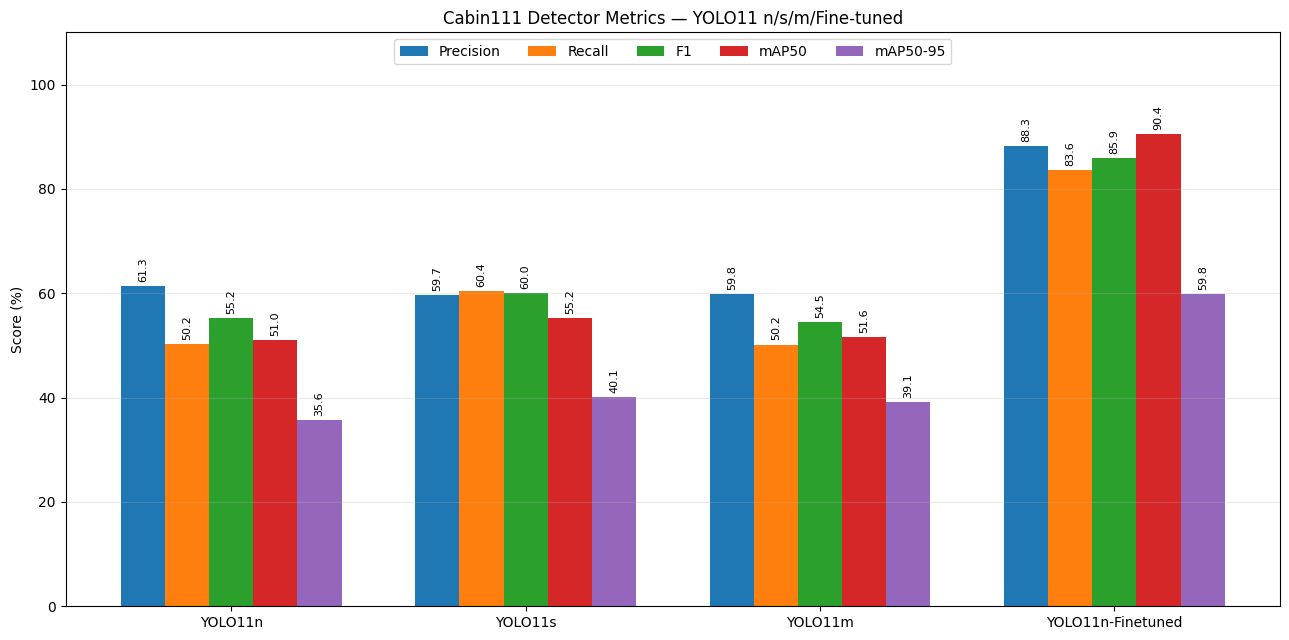

Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/PPT_Cabin111_detector_all_metrics.png


In [ ]:
# PPT 그래프 1
# Detector P/R/F1/mAP50/mAP50-95

det_plot = (
    detector_summary_df
    .set_index("Model")
    .reindex(MODEL_ORDER_EVAL)
)

det_metrics = [
    "Detector_Precision",
    "Detector_Recall",
    "Detector_F1",
    "mAP50",
    "mAP50_95",
]

det_labels = [
    "Precision",
    "Recall",
    "F1",
    "mAP50",
    "mAP50-95",
]

x = np.arange(
    len(MODEL_ORDER_EVAL)
)

width = 0.15

offsets = (
    np.arange(len(det_metrics))
    - (len(det_metrics) - 1) / 2
) * width

fig, ax = plt.subplots(
    figsize=(13.0, 6.5)
)

for offset, metric, label in zip(
    offsets,
    det_metrics,
    det_labels,
):
    values = (
        det_plot[metric]
        .to_numpy()
        * 100
    )

    bars = ax.bar(
        x + offset,
        values,
        width,
        label=label,
    )

    for bar, value in zip(
        bars,
        values,
    ):
        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
        )

ax.set_xticks(x)
ax.set_xticklabels(
    MODEL_ORDER_EVAL
)

ax.set_ylim(0, 110)
ax.set_ylabel("Score (%)")
ax.set_title(
    "Cabin111 Detector Metrics — YOLO11 n/s/m/Fine-tuned"
)
ax.legend(
    ncol=5,
    loc="upper center",
)
ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

DET_GRAPH = (
    RESULT_ROOT
    / "PPT_Cabin111_detector_all_metrics.png"
)

fig.savefig(
    DET_GRAPH,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

print("Saved:", DET_GRAPH)


## 13. Cabin 111장 End-to-End 비교

In [ ]:
cabin_gt_lookup = (
    cabin_gt_df
    .set_index("image")
)

cabin_rows = []

for model_name, spec in (
    MODEL_SPECS.items()
):
    model = spec["model"]

    print(
        "\n" + "=" * 70
    )
    print(
        model_name,
        "Cabin evaluation",
    )
    print(
        "=" * 70
    )

    for idx, image_path in enumerate(
        cabin_images,
        start=1,
    ):
        gt_object_raw = (
            cabin_gt_lookup.loc[
                image_path.name,
                "GT_Object",
            ]
        )

        gt_system = (
            "person"
            if gt_object_raw
            == "person"
            else "animal"
        )

        (
            gt_final,
            true_age,
        ) = get_cabin_gt_final(
            image_path.name,
            gt_object_raw,
        )

        bgr = cv2.imread(
            str(image_path)
        )

        if bgr is None:
            raise RuntimeError(
                f"읽기 실패: {image_path}"
            )

        h, w = bgr.shape[:2]

        result = model.predict(
            source=bgr,
            imgsz=IMGSZ,
            conf=CONF,
            classes=spec[
                "classes"
            ],
            device=DEVICE,
            verbose=False,
        )[0]

        boxes = result.boxes

        pred_system = "miss"
        pred_final = "miss"
        pred_age = np.nan
        pred_conf = np.nan

        if (
            boxes is not None
            and len(boxes) > 0
        ):
            confs = (
                boxes.conf
                .detach()
                .float()
                .cpu()
                .numpy()
            )

            best_idx = int(
                np.argmax(confs)
            )

            box = boxes[
                best_idx
            ]

            pred_cls = int(
                box.cls
                .detach()
                .cpu()
                .item()
            )

            pred_conf = float(
                box.conf
                .detach()
                .cpu()
                .item()
            )

            pred_system = (
                spec[
                    "class_to_object"
                ].get(
                    pred_cls,
                    "miss",
                )
            )

            if pred_system == "animal":
                pred_final = "animal"

            elif pred_system == "person":

                x1, y1, x2, y2 = (
                    box.xyxy[0]
                    .detach()
                    .float()
                    .cpu()
                    .numpy()
                    .tolist()
                )

                x1 = max(
                    0,
                    min(
                        w - 1,
                        int(np.floor(x1)),
                    ),
                )

                y1 = max(
                    0,
                    min(
                        h - 1,
                        int(np.floor(y1)),
                    ),
                )

                x2 = max(
                    1,
                    min(
                        w,
                        int(np.ceil(x2)),
                    ),
                )

                y2 = max(
                    1,
                    min(
                        h,
                        int(np.ceil(y2)),
                    ),
                )

                crop = bgr[
                    y1:y2,
                    x1:x2,
                ]

                try:
                    (
                        pred_age,
                        pred_final,
                    ) = (
                        predict_age_from_person_crop(
                            crop
                        )
                    )

                except Exception:
                    pred_final = "miss"

        cabin_rows.append({
            "Model": model_name,
            "image": image_path.name,

            "GT_Object": gt_object_raw,
            "GT_System": gt_system,
            "GT_Final": gt_final,
            "True_Age": true_age,

            "Pred_System": pred_system,
            "Pred_Final": pred_final,
            "Pred_Age": pred_age,
            "YOLO_Confidence":
                pred_conf,
        })

        if (
            idx % 20 == 0
            or idx == len(
                cabin_images
            )
        ):
            print(
                f"{idx}/"
                f"{len(cabin_images)}"
            )

cabin_pred_df = pd.DataFrame(
    cabin_rows
)

cabin_pred_df.to_csv(
    RESULT_ROOT
    / "cabin_4model_predictions_internal.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Cabin internal prediction complete:", len(cabin_pred_df), "rows")


YOLO11n Cabin evaluation
20/111
40/111
60/111
80/111
100/111
111/111

YOLO11s Cabin evaluation
20/111
40/111
60/111
80/111
100/111
111/111

YOLO11m Cabin evaluation
20/111
40/111
60/111
80/111
100/111
111/111

YOLO11n-Finetuned Cabin evaluation
20/111
40/111
60/111
80/111
100/111
111/111
Cabin internal prediction complete: 444 rows



## 14. Cabin 지표 계산


In [ ]:
FINAL_CLASSES = [
    "young",
    "old",
    "animal",
]

cabin_summary_rows = []

for model_name, g in (
    cabin_pred_df.groupby(
        "Model",
        sort=False,
    )
):
    # 1. System = person / animal
    sys_p, sys_r, sys_f1, sys_support = (
        precision_recall_fscore_support(
            g["GT_System"],
            g["Pred_System"],
            labels=[
                "person",
                "animal",
            ],
            average=None,
            zero_division=0,
        )
    )

    system_accuracy = accuracy_score(
        g["GT_System"],
        g["Pred_System"],
    )

    # 2. Final = young / old / animal
    fp, fr, ff1, fsupport = (
        precision_recall_fscore_support(
            g["GT_Final"],
            g["Pred_Final"],
            labels=FINAL_CLASSES,
            average=None,
            zero_division=0,
        )
    )

    final_accuracy = accuracy_score(
        g["GT_Final"],
        g["Pred_Final"],
    )

    # 3. Age MAE
    #    person 검출 + MiVOLO age 출력이 실제로 존재한 경우
    age_valid = g[
        (g["GT_System"] == "person")
        & (g["Pred_System"] == "person")
        & g["True_Age"].notna()
        & g["Pred_Age"].notna()
    ].copy()

    age_mae = (
        mean_absolute_error(
            age_valid["True_Age"],
            age_valid["Pred_Age"],
        )
        if len(age_valid)
        else np.nan
    )

    # 4. Detected-only MiVOLO 평가
    # GT가 person이고 YOLO도 person으로 검출한 경우만 남김.
    # 따라서 YOLO miss의 영향을 제거하고 MiVOLO age 판정만 봄.

    detected_person = g[
        (g["GT_System"] == "person")
        & (g["Pred_System"] == "person")
    ].copy()

    detected_only_age_accuracy = (
        float(
            (
                detected_person["GT_Final"]
                == detected_person["Pred_Final"]
            ).mean()
        )
        if len(detected_person)
        else np.nan
    )

    detected_young = detected_person[
        detected_person["GT_Final"] == "young"
    ]

    detected_old = detected_person[
        detected_person["GT_Final"] == "old"
    ]

    detected_only_young_accuracy = (
        float(
            (
                detected_young["Pred_Final"]
                == "young"
            ).mean()
        )
        if len(detected_young)
        else np.nan
    )

    detected_only_old_accuracy = (
        float(
            (
                detected_old["Pred_Final"]
                == "old"
            ).mean()
        )
        if len(detected_old)
        else np.nan
    )

    cabin_summary_rows.append({
        "Model": model_name,

        "System_Accuracy":
            system_accuracy,

        "Person_Recall":
            sys_r[0],

        "Animal_Recall":
            sys_r[1],

        "Final_Accuracy":
            final_accuracy,

        "Young_Recall":
            fr[0],

        "Old_Recall":
            fr[1],

        "Final_Animal_Recall":
            fr[2],

        "Detected_Only_Age_Accuracy":
            detected_only_age_accuracy,

        "Detected_Only_Young_Accuracy":
            detected_only_young_accuracy,

        "Detected_Only_Old_Accuracy":
            detected_only_old_accuracy,

        "Detected_Person_Count":
            len(detected_person),

        "Age_MAE":
            age_mae,
    })

cabin_summary_df = pd.DataFrame(
    cabin_summary_rows
)

cabin_summary_df.to_csv(
    RESULT_ROOT
    / "cabin_4model_summary_internal.csv",
    index=False,
    encoding="utf-8-sig",
)

cabin_display = cabin_summary_df.copy()

for col in [
    "System_Accuracy",
    "Person_Recall",
    "Animal_Recall",
    "Final_Accuracy",
    "Young_Recall",
    "Old_Recall",
    "Final_Animal_Recall",
    "Detected_Only_Age_Accuracy",
    "Detected_Only_Young_Accuracy",
    "Detected_Only_Old_Accuracy",
]:
    cabin_display[col] *= 100

print(
    "Cabin internal summary complete:",
    len(cabin_summary_df),
    "models"
)

Cabin internal summary complete: 4 models


# Part 3. UTKFace Balanced 100 — Unified211 생성을 위한 내부 prediction 계산

## 15. UTKFace Balanced 100 로드

In [ ]:

if UTK_ROOT is None:
    raise FileNotFoundError(
        "UTKFace Balanced 100 폴더를 찾지 못했습니다.\n\n"
        "필요 구조:\n"
        "UTKFace_balanced_100_yolo/\n"
        "├─ images/val/   <- 100장\n"
        "└─ labels.csv    <- image,true_age\n\n"
        "경로 설정 셀의 UTK_CANDIDATES에 실제 Drive 경로를 추가하세요."
    )

for p in [
    UTK_IMAGE_DIR,
    UTK_AGE_CSV,
]:
    if not p.exists():
        raise FileNotFoundError(
            p
        )

utk_images = sorted([
    p
    for p in UTK_IMAGE_DIR.iterdir()
    if p.is_file()
    and p.suffix.lower()
    in IMAGE_EXTS
])

utk_age_df = pd.read_csv(
    UTK_AGE_CSV
)

if not {
    "image",
    "true_age",
}.issubset(
    utk_age_df.columns
):
    raise ValueError(
        "UTK labels.csv에는 image,true_age가 필요합니다."
    )

utk_age_df = (
    utk_age_df[
        ["image", "true_age"]
    ]
    .copy()
)

utk_age_df[
    "true_age"
] = pd.to_numeric(
    utk_age_df[
        "true_age"
    ],
    errors="coerce",
)

if utk_age_df[
    "true_age"
].isna().any():
    raise ValueError(
        "UTK true_age에 숫자가 아닌 값이 있습니다."
    )

utk_lookup = (
    utk_age_df
    .drop_duplicates(
        subset=["image"]
    )
    .set_index("image")
)

young_n = int(
    (
        utk_age_df[
            "true_age"
        ] <= AGE_THRESHOLD
    ).sum()
)

old_n = int(
    (
        utk_age_df[
            "true_age"
        ] > AGE_THRESHOLD
    ).sum()
)

print(
    "UTK Root:",
    UTK_ROOT
)

print(
    "Images:",
    len(utk_images)
)

print(
    "Young:",
    young_n
)

print(
    "Old:",
    old_n
)


UTK Root: /content/drive/MyDrive/UTKFace_balanced_100_yolo
Images: 100
Young: 50
Old: 50


## 16. UTKFace Baseline vs Fine-tuned + MiVOLO

In [ ]:
utk_rows = []

for model_name, spec in (
    MODEL_SPECS.items()
):
    model = spec["model"]

    print(
        "\n" + "=" * 70
    )
    print(
        model_name,
        "UTK evaluation",
    )
    print(
        "=" * 70
    )

    for idx, image_path in enumerate(
        utk_images,
        start=1,
    ):
        true_age = float(
            utk_lookup.loc[
                image_path.name,
                "true_age",
            ]
        )

        gt_class = (
            "young"
            if true_age <= AGE_THRESHOLD
            else "old"
        )

        bgr = cv2.imread(
            str(image_path)
        )

        if bgr is None:
            raise RuntimeError(
                image_path
            )

        h, w = bgr.shape[:2]

        # UTK에서는 person class만 추론
        result = model.predict(
            source=bgr,
            imgsz=IMGSZ,
            conf=CONF,
            classes=[0],
            device=DEVICE,
            verbose=False,
        )[0]

        boxes = result.boxes

        detected = (
            boxes is not None
            and len(boxes) > 0
        )

        pred_age = np.nan
        pred_class = "miss"
        confidence = np.nan

        if detected:
            confs = (
                boxes.conf
                .detach()
                .float()
                .cpu()
                .numpy()
            )

            best_idx = int(
                np.argmax(confs)
            )

            box = boxes[
                best_idx
            ]

            confidence = float(
                box.conf
                .detach()
                .cpu()
                .item()
            )

            x1, y1, x2, y2 = (
                box.xyxy[0]
                .detach()
                .float()
                .cpu()
                .numpy()
                .tolist()
            )

            x1 = max(
                0,
                min(
                    w - 1,
                    int(np.floor(x1)),
                ),
            )

            y1 = max(
                0,
                min(
                    h - 1,
                    int(np.floor(y1)),
                ),
            )

            x2 = max(
                1,
                min(
                    w,
                    int(np.ceil(x2)),
                ),
            )

            y2 = max(
                1,
                min(
                    h,
                    int(np.ceil(y2)),
                ),
            )

            crop = bgr[
                y1:y2,
                x1:x2,
            ]

            try:
                (
                    pred_age,
                    pred_class,
                ) = (
                    predict_age_from_person_crop(
                        crop
                    )
                )
            except Exception:
                pred_class = "miss"

        utk_rows.append({
            "Model": model_name,
            "image": image_path.name,
            "True_Age": true_age,
            "GT_Class": gt_class,
            "Person_Detected":
                bool(detected),
            "YOLO_Confidence":
                confidence,
            "Pred_Age": pred_age,
            "Pred_Class":
                pred_class,
            "Correct":
                pred_class
                == gt_class,
        })

        if (
            idx % 20 == 0
            or idx == len(
                utk_images
            )
        ):
            print(
                f"{idx}/"
                f"{len(utk_images)}"
            )

utk_pred_df = pd.DataFrame(
    utk_rows
)

utk_pred_df.to_csv(
    RESULT_ROOT
    / "utk_4model_predictions_internal.csv",
    index=False,
    encoding="utf-8-sig",
)

print("UTK internal prediction complete:", len(utk_pred_df), "rows")


YOLO11n UTK evaluation
20/100
40/100
60/100
80/100
100/100

YOLO11s UTK evaluation
20/100
40/100
60/100
80/100
100/100

YOLO11m UTK evaluation
20/100
40/100
60/100
80/100
100/100

YOLO11n-Finetuned UTK evaluation
20/100
40/100
60/100
80/100
100/100
UTK internal prediction complete: 400 rows



## 17. UTKFace 지표 계산

### End-to-End
### Detected-only MiVOLO


In [ ]:
def safe_div(a, b):
    return (
        float(a / b)
        if b > 0
        else np.nan
    )


def f1_from_pr(p, r):
    if (
        pd.isna(p)
        or pd.isna(r)
        or p + r == 0
    ):
        return np.nan

    return (
        2 * p * r
        / (p + r)
    )


utk_summary_rows = []

for model_name, g in (
    utk_pred_df.groupby(
        "Model",
        sort=False,
    )
):
    total = len(g)

    detected = int(
        g[
            "Person_Detected"
        ].sum()
    )

    det_rate = safe_div(
        detected,
        total,
    )

    # End-to-End young / old 지표
    # YOLO miss도 최종 실패로 포함
    gt_young = (
        g["GT_Class"]
        == "young"
    )

    gt_old = (
        g["GT_Class"]
        == "old"
    )

    pred_young = (
        g["Pred_Class"]
        == "young"
    )

    pred_old = (
        g["Pred_Class"]
        == "old"
    )

    y_tp = int(
        (
            gt_young
            & pred_young
        ).sum()
    )

    y_fp = int(
        (
            ~gt_young
            & pred_young
        ).sum()
    )

    y_fn = int(
        (
            gt_young
            & ~pred_young
        ).sum()
    )

    o_tp = int(
        (
            gt_old
            & pred_old
        ).sum()
    )

    o_fp = int(
        (
            ~gt_old
            & pred_old
        ).sum()
    )

    o_fn = int(
        (
            gt_old
            & ~pred_old
        ).sum()
    )

    young_p = safe_div(
        y_tp,
        y_tp + y_fp,
    )

    young_r = safe_div(
        y_tp,
        y_tp + y_fn,
    )

    old_p = safe_div(
        o_tp,
        o_tp + o_fp,
    )

    old_r = safe_div(
        o_tp,
        o_tp + o_fn,
    )

    # Detected-only MiVOLO 지표

    # YOLO가 person을 찾은 이미지에서만 age 판정을 평가.
    # 이 값이 유지되는데 Young Recall만 떨어진다면
    # MiVOLO보다 YOLO person detection 문제로 해석 가능.

    detected_g = g[
        g["Person_Detected"]
    ].copy()

    detected_only_age_accuracy = (
        float(
            detected_g[
                "Correct"
            ].mean()
        )
        if len(detected_g)
        else np.nan
    )

    detected_young = detected_g[
        detected_g["GT_Class"]
        == "young"
    ]

    detected_old = detected_g[
        detected_g["GT_Class"]
        == "old"
    ]

    detected_only_young_accuracy = (
        float(
            (
                detected_young["Pred_Class"]
                == "young"
            ).mean()
        )
        if len(detected_young)
        else np.nan
    )

    detected_only_old_accuracy = (
        float(
            (
                detected_old["Pred_Class"]
                == "old"
            ).mean()
        )
        if len(detected_old)
        else np.nan
    )

    # Age MAE
    age_valid = g[
        g["Pred_Age"].notna()
    ].copy()

    age_mae = (
        mean_absolute_error(
            age_valid[
                "True_Age"
            ],
            age_valid[
                "Pred_Age"
            ],
        )
        if len(age_valid)
        else np.nan
    )

    utk_summary_rows.append({
        "Model": model_name,

        "Person_Detection_Rate":
            det_rate,

        "Young_Precision":
            young_p,

        "Young_Recall":
            young_r,

        "Young_F1":
            f1_from_pr(
                young_p,
                young_r,
            ),

        "Old_Precision":
            old_p,

        "Old_Recall":
            old_r,

        "Old_F1":
            f1_from_pr(
                old_p,
                old_r,
            ),

        "End_to_End_Accuracy":
            float(
                g["Correct"].mean()
            ),

        "Detected_Only_Age_Accuracy":
            detected_only_age_accuracy,

        "Detected_Only_Young_Accuracy":
            detected_only_young_accuracy,

        "Detected_Only_Old_Accuracy":
            detected_only_old_accuracy,

        "Detected_Person_Count":
            detected,

        "Age_MAE":
            age_mae,
    })

utk_summary_df = pd.DataFrame(
    utk_summary_rows
)

utk_summary_df.to_csv(
    RESULT_ROOT
    / "utk_4model_summary_internal.csv",
    index=False,
    encoding="utf-8-sig",
)

utk_display = utk_summary_df.copy()

for col in [
    "Person_Detection_Rate",
    "Young_Precision",
    "Young_Recall",
    "Young_F1",
    "Old_Precision",
    "Old_Recall",
    "Old_F1",
    "End_to_End_Accuracy",
    "Detected_Only_Age_Accuracy",
    "Detected_Only_Young_Accuracy",
    "Detected_Only_Old_Accuracy",
]:
    utk_display[col] *= 100

print(
    "UTK internal summary complete:",
    len(utk_summary_df),
    "models"
)

UTK internal summary complete: 4 models


# Part 4. Unified Evaluation 211 — 4개 모델 한 번에 비교


In [ ]:
# 18. Cabin + UTK sample-level prediction 직접 결합

# Cabin 111
cabin_unified = cabin_pred_df[
    [
        "Model",
        "image",
        "GT_Final",
        "Pred_Final",
        "True_Age",
        "Pred_Age",
        "GT_System",
        "Pred_System",
    ]
].copy()

cabin_unified["Dataset"] = "Cabin"

cabin_unified["GT_Class"] = (
    cabin_unified["GT_Final"]
)

cabin_unified["Pred_Class"] = (
    cabin_unified["Pred_Final"]
)

# Person GT sample에서 YOLO가 person으로 routing했는지
cabin_unified["Person_Detected"] = (
    (
        cabin_unified["GT_Class"].isin(
            ["young", "old"]
        )
    )
    &
    (
        cabin_unified["Pred_System"]
        == "person"
    )
)

cabin_unified = cabin_unified[
    [
        "Model",
        "Dataset",
        "image",
        "GT_Class",
        "Pred_Class",
        "True_Age",
        "Pred_Age",
        "Person_Detected",
    ]
].copy()


# UTKFace 100
utk_unified = utk_pred_df[
    [
        "Model",
        "image",
        "GT_Class",
        "Pred_Class",
        "True_Age",
        "Pred_Age",
        "Person_Detected",
    ]
].copy()

utk_unified["Dataset"] = "UTK"

utk_unified = utk_unified[
    [
        "Model",
        "Dataset",
        "image",
        "GT_Class",
        "Pred_Class",
        "True_Age",
        "Pred_Age",
        "Person_Detected",
    ]
].copy()


# TRUE Unified Evaluation 211
combined_pred_df = pd.concat(
    [
        cabin_unified,
        utk_unified,
    ],
    ignore_index=True,
)

combined_pred_df["Sample_ID"] = (
    combined_pred_df["Dataset"]
    + "::"
    + combined_pred_df["image"]
)

combined_pred_df["Correct"] = (
    combined_pred_df["GT_Class"]
    == combined_pred_df["Pred_Class"]
)

MODEL_ORDER = [
    "YOLO11n",
    "YOLO11s",
    "YOLO11m",
    "YOLO11n-Finetuned",
]

combined_pred_df["Model"] = pd.Categorical(
    combined_pred_df["Model"],
    categories=MODEL_ORDER,
    ordered=True,
)

combined_pred_df = (
    combined_pred_df
    .sort_values(
        ["Model", "Dataset", "image"]
    )
    .reset_index(drop=True)
)

COMBINED_PRED_CSV = (
    RESULT_ROOT
    / "Unified211_4model_per_image_predictions.csv"
)

combined_pred_df.to_csv(
    COMBINED_PRED_CSV,
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", COMBINED_PRED_CSV)
print()
print(
    combined_pred_df.groupby(
        "Model",
        observed=True,
    ).size()
)


Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/Unified211_4model_per_image_predictions.csv

Model
YOLO11n              211
YOLO11s              211
YOLO11m              211
YOLO11n-Finetuned    211
dtype: int64


## 19. Unified211 데이터 구성 검증

```text
Total  = 211
Young  = 81
Old    = 70
Animal = 60
```



In [ ]:
# Unified211 support 검사

support_check = (
    combined_pred_df
    .groupby(
        ["Model", "GT_Class"],
        observed=True,
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        index=MODEL_ORDER,
        columns=[
            "young",
            "old",
            "animal",
        ],
        fill_value=0,
    )
)

support_check["Total"] = (
    support_check.sum(axis=1)
)

display(support_check)

EXPECTED_SUPPORT = {
    "young": 81,
    "old": 70,
    "animal": 60,
    "Total": 211,
}

for model_name in MODEL_ORDER:
    for key, expected in EXPECTED_SUPPORT.items():
        actual = int(
            support_check.loc[
                model_name,
                key,
            ]
        )

        if actual != expected:
            raise ValueError(
                f"{model_name} {key}: "
                f"expected={expected}, "
                f"actual={actual}"
            )

print("Unified211 support check: PASS")


GT_Class,young,old,animal,Total
Model,,,,
YOLO11n,81,70,60,211
YOLO11s,81,70,60,211
YOLO11m,81,70,60,211
YOLO11n-Finetuned,81,70,60,211


Unified211 support check: PASS


## Unified211 4-model 최종 End-to-End 성능 계산

```text
Final Accuracy

Macro Precision
Macro Recall
Macro F1

Young Precision
Young Recall
Young F1

Old Precision
Old Recall
Old F1

Animal Precision
Animal Recall
Animal F1

Person Detection Rate
Age MAE
```


In [ ]:
# Unified211 metric 계산

FINAL_CLASSES = [
    "young",
    "old",
    "animal",
]

combined_summary_rows = []

for model_name in MODEL_ORDER:

    g = (
        combined_pred_df[
            combined_pred_df["Model"]
            == model_name
        ]
        .copy()
    )

    # Final young / old / animal
    # miss도 그대로 포함되어 FN으로 반영됨
    p, r, f1, support = (
        precision_recall_fscore_support(
            g["GT_Class"],
            g["Pred_Class"],
            labels=FINAL_CLASSES,
            average=None,
            zero_division=0,
        )
    )

    macro_p, macro_r, macro_f1, _ = (
        precision_recall_fscore_support(
            g["GT_Class"],
            g["Pred_Class"],
            labels=FINAL_CLASSES,
            average="macro",
            zero_division=0,
        )
    )

    final_accuracy = float(
        accuracy_score(
            g["GT_Class"],
            g["Pred_Class"],
        )
    )

    # 전체 person sample = Young 81 + Old 70 = 151
    # Cabin + UTK를 모두 포함한 Person Detection Rate
    person_gt = g[
        g["GT_Class"].isin(
            ["young", "old"]
        )
    ].copy()

    person_detection_rate = float(
        person_gt[
            "Person_Detected"
        ].mean()
    )

    # Age MAE
    # 실제 나이가 있고 MiVOLO output이 존재한 sample만
    age_valid = g[
        g["GT_Class"].isin(
            ["young", "old"]
        )
        & g["True_Age"].notna()
        & g["Pred_Age"].notna()
    ].copy()

    age_mae = (
        float(
            mean_absolute_error(
                age_valid["True_Age"],
                age_valid["Pred_Age"],
            )
        )
        if len(age_valid)
        else np.nan
    )

    combined_summary_rows.append({
        "Model": model_name,
        "Total_Samples": len(g),

        "Final_Accuracy":
            final_accuracy,

        "Macro_Precision":
            float(macro_p),

        "Macro_Recall":
            float(macro_r),

        "Macro_F1":
            float(macro_f1),

        "Young_Precision":
            float(p[0]),

        "Young_Recall":
            float(r[0]),

        "Young_F1":
            float(f1[0]),

        "Young_Support":
            int(support[0]),

        "Old_Precision":
            float(p[1]),

        "Old_Recall":
            float(r[1]),

        "Old_F1":
            float(f1[1]),

        "Old_Support":
            int(support[1]),

        "Animal_Precision":
            float(p[2]),

        "Animal_Recall":
            float(r[2]),

        "Animal_F1":
            float(f1[2]),

        "Animal_Support":
            int(support[2]),

        "Person_Detection_Rate":
            person_detection_rate,

        "Detected_Person_Count":
            int(
                person_gt[
                    "Person_Detected"
                ].sum()
            ),

        "Person_Support":
            len(person_gt),

        "Age_MAE":
            age_mae,

        "Age_Output_Count":
            len(age_valid),
    })

combined_summary_df = pd.DataFrame(
    combined_summary_rows
)

COMBINED_SUMMARY_CSV = (
    RESULT_ROOT
    / "Unified211_4model_summary.csv"
)

combined_summary_df.to_csv(
    COMBINED_SUMMARY_CSV,
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", COMBINED_SUMMARY_CSV)


Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/Unified211_4model_summary.csv


# PPT 핵심 결과 1. Unified211 4개 모델 비교표

이 표 하나를 메인 모델 성능 비교표로 사용하면 됩니다.


In [ ]:
# PPT/분석용 Unified211 전체 지표 비교표

unified_all_cols = [
    "Model",
    "Final_Accuracy",

    "Macro_Precision",
    "Macro_Recall",
    "Macro_F1",

    "Young_Precision",
    "Young_Recall",
    "Young_F1",

    "Old_Precision",
    "Old_Recall",
    "Old_F1",

    "Animal_Precision",
    "Animal_Recall",
    "Animal_F1",

    "Person_Detection_Rate",
    "Age_MAE",

    "Young_Support",
    "Old_Support",
    "Animal_Support",
    "Person_Support",
]

unified_all_table = (
    combined_summary_df[
        unified_all_cols
    ]
    .copy()
)

unified_percent_cols = [
    "Final_Accuracy",

    "Macro_Precision",
    "Macro_Recall",
    "Macro_F1",

    "Young_Precision",
    "Young_Recall",
    "Young_F1",

    "Old_Precision",
    "Old_Recall",
    "Old_F1",

    "Animal_Precision",
    "Animal_Recall",
    "Animal_F1",

    "Person_Detection_Rate",
]

unified_all_display = (
    unified_all_table.copy()
)

unified_all_display[
    unified_percent_cols
] *= 100.0

display(
    unified_all_display.round(2)
)

UNIFIED_ALL_CSV = (
    RESULT_ROOT
    / "Unified211_4model_ALL_metrics.csv"
)

unified_all_table.to_csv(
    UNIFIED_ALL_CSV,
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", UNIFIED_ALL_CSV)


,Model,Final_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Young_Precision,Young_Recall,Young_F1,Old_Precision,Old_Recall,Old_F1,Animal_Precision,Animal_Recall,Animal_F1,Person_Detection_Rate,Age_MAE,Young_Support,Old_Support,Animal_Support,Person_Support
0,YOLO11n,79.15,97.71,79.71,87.74,98.39,75.31,85.31,94.74,77.14,85.04,100.0,86.67,92.86,78.81,2.29,81,70,60,151
1,YOLO11s,81.99,97.35,83.15,89.37,100.00,71.60,83.45,92.06,82.86,87.22,100.0,95.00,97.44,80.13,2.31,81,70,60,151
2,YOLO11m,79.62,97.27,80.97,87.94,100.00,67.90,80.88,91.80,80.00,85.50,100.0,95.00,97.44,76.82,2.22,81,70,60,151
3,YOLO11n-Finetuned,95.26,96.83,95.40,96.09,97.44,93.83,95.60,93.06,95.71,94.37,100.0,96.67,98.31,99.34,1.93,81,70,60,151


Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/Unified211_4model_ALL_metrics.csv


# 최종 Master Table — 4개 모델 모든 핵심 지표 한 번에 비교


In [ ]:
# Detector + Unified211 MASTER TABLE

master_4model_df = (
    detector_summary_df
    .merge(
        combined_summary_df,
        on="Model",
        how="inner",
    )
)

MASTER_COLS = [
    "Model",

    # Detector — Cabin111
    "Detector_Precision",
    "Detector_Recall",
    "Detector_F1",
    "mAP50",
    "mAP50_95",

    # Unified211 overall
    "Final_Accuracy",
    "Macro_Precision",
    "Macro_Recall",
    "Macro_F1",

    # Unified211 Young
    "Young_Precision",
    "Young_Recall",
    "Young_F1",

    # Unified211 Old
    "Old_Precision",
    "Old_Recall",
    "Old_F1",

    # Unified211 Animal
    "Animal_Precision",
    "Animal_Recall",
    "Animal_F1",

    # Additional
    "Person_Detection_Rate",
    "Age_MAE",
]

master_4model_df = (
    master_4model_df[
        MASTER_COLS
    ]
    .copy()
)

master_percent_cols = [
    c
    for c in MASTER_COLS
    if c not in [
        "Model",
        "Age_MAE",
    ]
]

master_display = (
    master_4model_df.copy()
)

master_display[
    master_percent_cols
] *= 100.0

display(
    master_display.round(2)
)

MASTER_CSV = (
    RESULT_ROOT
    / "FINAL_4MODEL_MASTER_ALL_METRICS.csv"
)

master_4model_df.to_csv(
    MASTER_CSV,
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", MASTER_CSV)


,Model,Detector_Precision,Detector_Recall,Detector_F1,mAP50,mAP50_95,Final_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,...,Young_Recall,Young_F1,Old_Precision,Old_Recall,Old_F1,Animal_Precision,Animal_Recall,Animal_F1,Person_Detection_Rate,Age_MAE
0,YOLO11n,61.30,50.20,55.20,51.00,35.64,79.15,97.71,79.71,87.74,...,75.31,85.31,94.74,77.14,85.04,100.0,86.67,92.86,78.81,2.29
1,YOLO11s,59.70,60.39,60.04,55.22,40.06,81.99,97.35,83.15,89.37,...,71.60,83.45,92.06,82.86,87.22,100.0,95.00,97.44,80.13,2.31
2,YOLO11m,59.76,50.16,54.54,51.65,39.09,79.62,97.27,80.97,87.94,...,67.90,80.88,91.80,80.00,85.50,100.0,95.00,97.44,76.82,2.22
3,YOLO11n-Finetuned,88.28,83.59,85.87,90.44,59.77,95.26,96.83,95.40,96.09,...,93.83,95.60,93.06,95.71,94.37,100.0,96.67,98.31,99.34,1.93


Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/FINAL_4MODEL_MASTER_ALL_METRICS.csv


## Detector class별 전체 지표 Pivot Table

person / cat / dog별 P/R/F1/AP50/AP50-95


In [ ]:
# Detector class별 metric pivot

if len(detector_class_df):

    class_metric_pivot = (
        detector_class_df
        .pivot(
            index="Model",
            columns="Class",
            values=[
                "Precision",
                "Recall",
                "F1",
                "AP50",
                "AP50_95",
            ],
        )
        .reindex(MODEL_ORDER_EVAL)
    )

    class_metric_display = (
        class_metric_pivot
        * 100.0
    )

    display(
        class_metric_display.round(2)
    )

    CLASS_PIVOT_CSV = (
        RESULT_ROOT
        / "Cabin111_detector_class_metrics_pivot.csv"
    )

    class_metric_pivot.to_csv(
        CLASS_PIVOT_CSV,
        encoding="utf-8-sig",
    )

    print("Saved:", CLASS_PIVOT_CSV)


Precision                Recall                   F1         \
Class                   cat     dog person    cat    dog person    cat    dog   
Model                                                                           
YOLO11n               13.87   99.23  70.81  10.00  70.00  70.59  11.62  82.09   
YOLO11s               10.91   99.90  68.30  10.00  96.67  74.51  10.44  98.26   
YOLO11m                7.40  100.00  71.89   6.67  75.19  68.63   7.01  85.84   
YOLO11n-Finetuned     88.93   89.59  86.31  93.33  96.67  60.78  91.08  92.99   

                           AP50               AP50_95                
Class             person    cat    dog person     cat    dog person  
Model                                                                
YOLO11n            70.70   4.45  90.96  57.61    1.19  81.91  23.81  
YOLO11s            71.27   7.51  99.07  59.09    1.30  93.69  25.19  
YOLO11m            70.22   0.96  97.66  56.32    0.23  91.83  25.22  
YOLO11n-Finetuned  71.33  96.03  97.63  77.65   74.57  78.29  26.45

Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/Cabin111_detector_class_metrics_pivot.csv


# PPT 핵심 결과 2. n / s / m / Fine-tuned 정확성 그래프

```text
Final Accuracy
Young Recall
Animal Recall
```

```text
Original n/s/m 비교
        ↓
YOLO11n의 Young Recall 강점 확인
        ↓
Fine-tuning 후 Animal Recall 개선 여부
+
Young Recall 보존/향상 여부
```



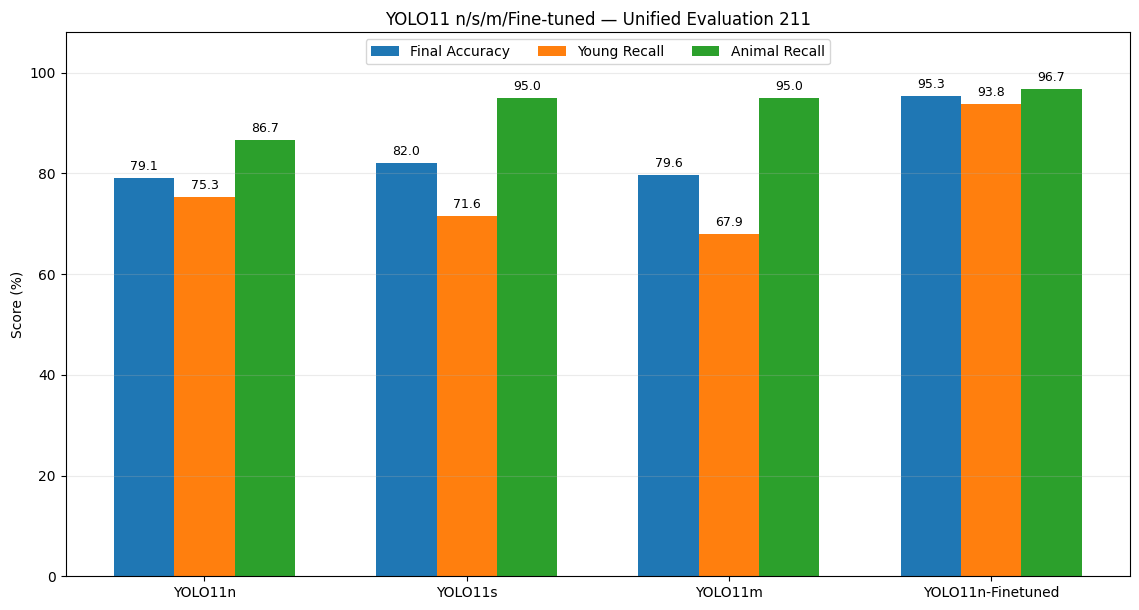

Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/PPT_Unified211_4model_accuracy.png


In [ ]:
# PPT 그래프 — Unified211 Accuracy / Young / Animal

plot_df = (
    combined_summary_df
    .set_index("Model")
    .reindex(MODEL_ORDER)
)

metrics = [
    "Final_Accuracy",
    "Young_Recall",
    "Animal_Recall",
]

labels = [
    "Final Accuracy",
    "Young Recall",
    "Animal Recall",
]

x = np.arange(
    len(MODEL_ORDER)
)

width = 0.23

offsets = (
    np.arange(len(metrics))
    - (len(metrics) - 1) / 2
) * width

fig, ax = plt.subplots(
    figsize=(11.5, 6.2)
)

for offset, metric, label in zip(
    offsets,
    metrics,
    labels,
):
    values = (
        plot_df[metric]
        .to_numpy()
        * 100.0
    )

    bars = ax.bar(
        x + offset,
        values,
        width,
        label=label,
    )

    for bar, value in zip(
        bars,
        values,
    ):
        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height() + 1.0,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_xticks(x)

ax.set_xticklabels(
    MODEL_ORDER
)

ax.set_ylim(0, 108)
ax.set_ylabel("Score (%)")

ax.set_title(
    "YOLO11 n/s/m/Fine-tuned — Unified Evaluation 211"
)

ax.legend(
    ncol=3,
    loc="upper center",
)

ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

PPT_GRAPH = (
    RESULT_ROOT
    / "PPT_Unified211_4model_accuracy.png"
)

fig.savefig(
    PPT_GRAPH,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

print("Saved:", PPT_GRAPH)


## Unified211 Overall Accuracy / Macro P/R/F1

최종 211개 전체에 대한 overall 분류 성능을 비교합니다.


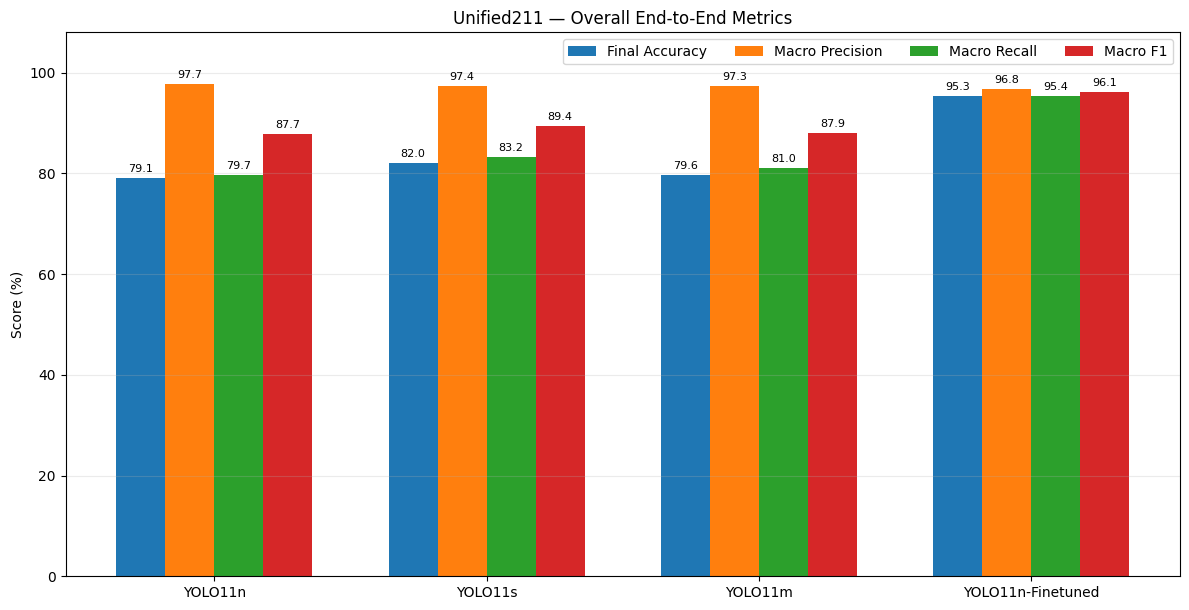

Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/PPT_Unified211_overall_PRF1.png


In [ ]:
# Unified211 Final Accuracy + Macro P/R/F1

overall_plot = (
    combined_summary_df
    .set_index("Model")
    .reindex(MODEL_ORDER)
)

overall_metrics = [
    "Final_Accuracy",
    "Macro_Precision",
    "Macro_Recall",
    "Macro_F1",
]

overall_labels = [
    "Final Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
]

x = np.arange(
    len(MODEL_ORDER)
)

width = 0.18

offsets = (
    np.arange(len(overall_metrics))
    - (len(overall_metrics) - 1) / 2
) * width

fig, ax = plt.subplots(
    figsize=(12.0, 6.2)
)

for offset, metric, label in zip(
    offsets,
    overall_metrics,
    overall_labels,
):
    values = (
        overall_plot[metric]
        .to_numpy()
        * 100
    )

    bars = ax.bar(
        x + offset,
        values,
        width,
        label=label,
    )

    for bar, value in zip(
        bars,
        values,
    ):
        ax.text(
            bar.get_x()
            + bar.get_width()/2,
            bar.get_height() + 0.8,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER)
ax.set_ylim(0, 108)
ax.set_ylabel("Score (%)")
ax.set_title(
    "Unified211 — Overall End-to-End Metrics"
)
ax.legend(ncol=4)
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

OVERALL_GRAPH = (
    RESULT_ROOT
    / "PPT_Unified211_overall_PRF1.png"
)

fig.savefig(
    OVERALL_GRAPH,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

print("Saved:", OVERALL_GRAPH)


## Unified211 class별 Precision / Recall / F1

Young / Old / Animal 각각의 P/R/F1을 모두 확인합니다.


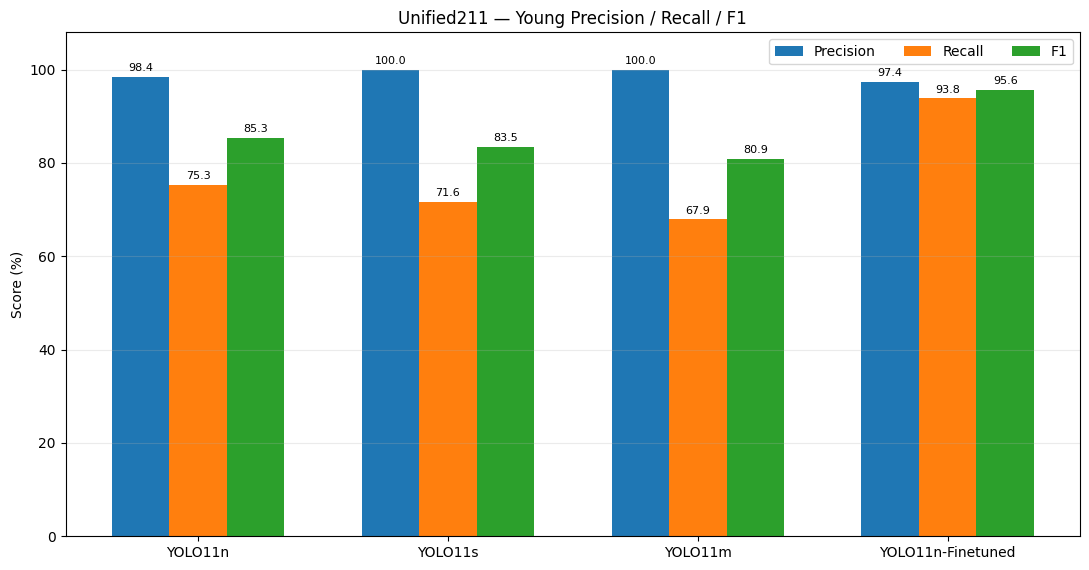

Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/PPT_Unified211_young_PRF1.png


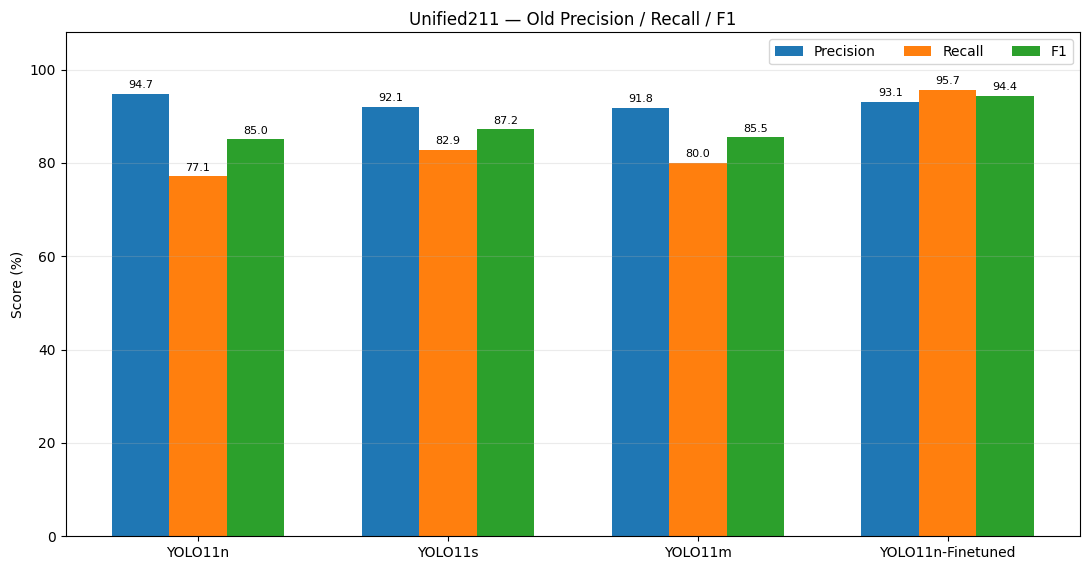

Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/PPT_Unified211_old_PRF1.png


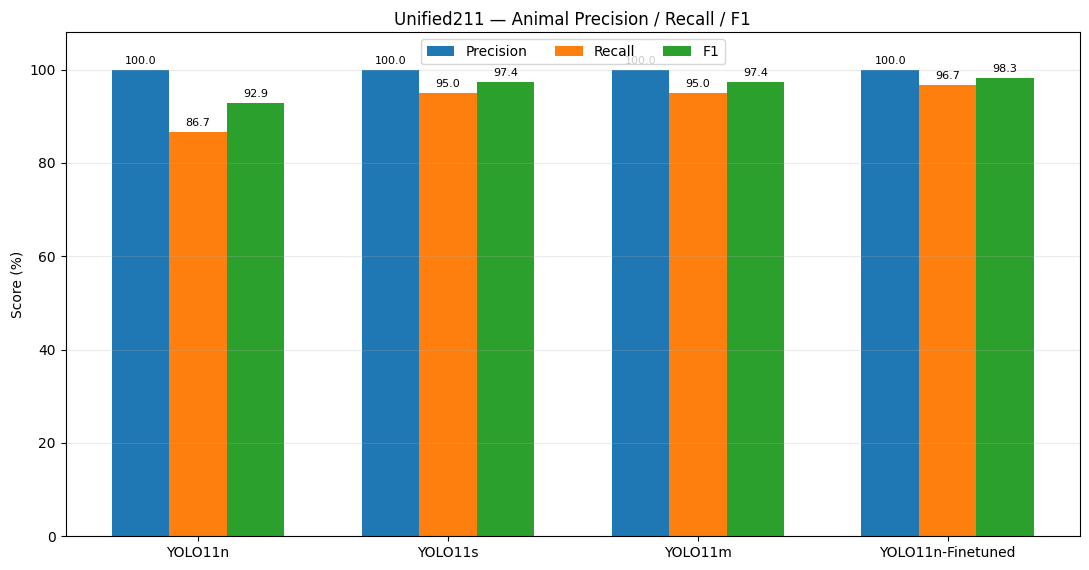

Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/PPT_Unified211_animal_PRF1.png


In [ ]:
# Unified211 class별 P/R/F1 — model별 3개 graph

class_prf_metrics = {
    "Young": [
        "Young_Precision",
        "Young_Recall",
        "Young_F1",
    ],
    "Old": [
        "Old_Precision",
        "Old_Recall",
        "Old_F1",
    ],
    "Animal": [
        "Animal_Precision",
        "Animal_Recall",
        "Animal_F1",
    ],
}

class_prf_files = []

for class_name, metric_cols in (
    class_prf_metrics.items()
):

    prf_plot = (
        combined_summary_df
        .set_index("Model")
        .reindex(MODEL_ORDER)
    )

    labels = [
        "Precision",
        "Recall",
        "F1",
    ]

    x = np.arange(
        len(MODEL_ORDER)
    )

    width = 0.23

    offsets = (
        np.arange(3) - 1
    ) * width

    fig, ax = plt.subplots(
        figsize=(11.0, 5.8)
    )

    for offset, metric, label in zip(
        offsets,
        metric_cols,
        labels,
    ):
        values = (
            prf_plot[metric]
            .to_numpy()
            * 100
        )

        bars = ax.bar(
            x + offset,
            values,
            width,
            label=label,
        )

        for bar, value in zip(
            bars,
            values,
        ):
            ax.text(
                bar.get_x()
                + bar.get_width()/2,
                bar.get_height() + 0.8,
                f"{value:.1f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(
        MODEL_ORDER
    )

    ax.set_ylim(0, 108)
    ax.set_ylabel("Score (%)")

    ax.set_title(
        f"Unified211 — {class_name} Precision / Recall / F1"
    )

    ax.legend(ncol=3)
    ax.grid(axis="y", alpha=0.25)

    fig.tight_layout()

    graph_path = (
        RESULT_ROOT
        / (
            "PPT_Unified211_"
            f"{class_name.lower()}_PRF1.png"
        )
    )

    fig.savefig(
        graph_path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()

    class_prf_files.append(
        graph_path
    )

    print("Saved:", graph_path)


## 21. Class Recall 비교 그래프

Young / Old / Animal Recall만 따로 비교하여
Fine-tuning 전후의 class별 변화


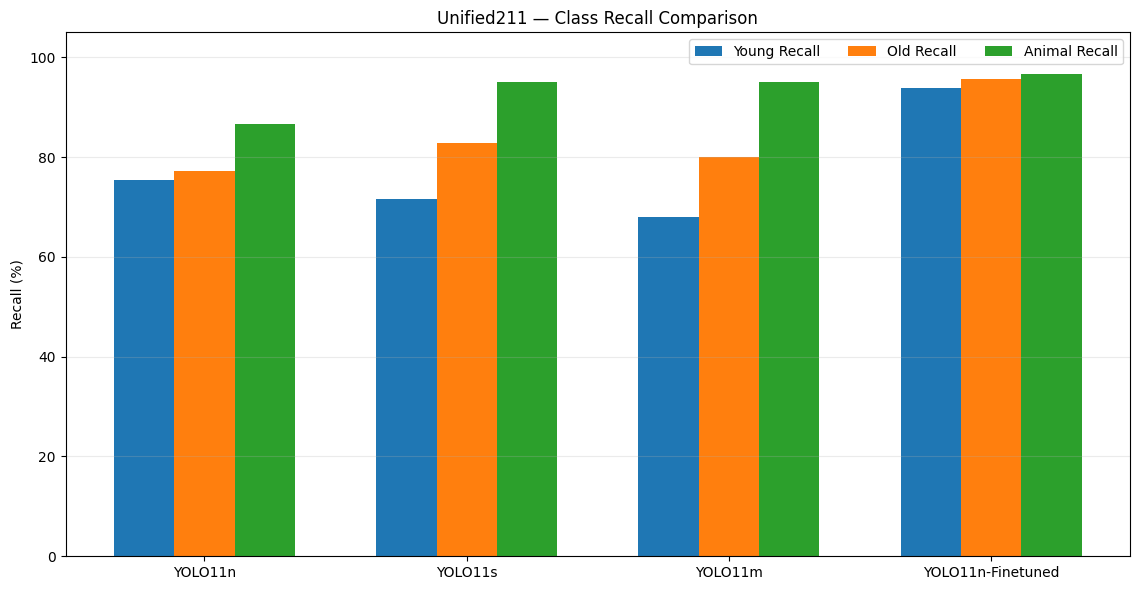

Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/Unified211_class_recall_comparison.png


In [ ]:
# Young / Old / Animal Recall

plot_df = (
    combined_summary_df
    .set_index("Model")
    .reindex(MODEL_ORDER)
)

metrics = [
    "Young_Recall",
    "Old_Recall",
    "Animal_Recall",
]

labels = [
    "Young Recall",
    "Old Recall",
    "Animal Recall",
]

x = np.arange(
    len(MODEL_ORDER)
)

width = 0.23

offsets = (
    np.arange(len(metrics))
    - (len(metrics) - 1) / 2
) * width

fig, ax = plt.subplots(
    figsize=(11.5, 6.0)
)

for offset, metric, label in zip(
    offsets,
    metrics,
    labels,
):
    ax.bar(
        x + offset,
        plot_df[metric].to_numpy() * 100,
        width,
        label=label,
    )

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER)
ax.set_ylim(0, 105)
ax.set_ylabel("Recall (%)")
ax.set_title(
    "Unified211 — Class Recall Comparison"
)
ax.legend(ncol=3)
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

CLASS_GRAPH = (
    RESULT_ROOT
    / "Unified211_class_recall_comparison.png"
)

fig.savefig(
    CLASS_GRAPH,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

print("Saved:", CLASS_GRAPH)


# PPT 핵심 결과 3. YOLO11n Fine-tuning 전후 변화

Fine-tuning 목적

```text
1. Animal Recall 개선
2. 기존 YOLO11n의 Young Recall 보존 또는 향상
```



In [ ]:
# Original n -> Fine-tuned n 변화량

base_n = (
    combined_summary_df
    .set_index("Model")
    .loc["YOLO11n"]
)

ft_n = (
    combined_summary_df
    .set_index("Model")
    .loc["YOLO11n-Finetuned"]
)

delta_metrics = [
    ("Final Accuracy", "Final_Accuracy"),
    ("Young Recall", "Young_Recall"),
    ("Old Recall", "Old_Recall"),
    ("Animal Recall", "Animal_Recall"),
    (
        "Person Detection Rate",
        "Person_Detection_Rate",
    ),
]

delta_rows = []

for label, col in delta_metrics:

    before = float(
        base_n[col]
    ) * 100

    after = float(
        ft_n[col]
    ) * 100

    delta_rows.append({
        "Metric": label,
        "Original_YOLO11n_%":
            before,
        "FineTuned_YOLO11n_%":
            after,
        "Change_%p":
            after - before,
    })

finetune_delta_df = pd.DataFrame(
    delta_rows
).round(2)

display(
    finetune_delta_df
)

DELTA_CSV = (
    RESULT_ROOT
    / "PPT_Finetuning_before_after_delta.csv"
)

finetune_delta_df.to_csv(
    DELTA_CSV,
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", DELTA_CSV)


,Metric,Original_YOLO11n_%,FineTuned_YOLO11n_%,Change_%p
0,Final Accuracy,79.15,95.26,16.11
1,Young Recall,75.31,93.83,18.52
2,Old Recall,77.14,95.71,18.57
3,Animal Recall,86.67,96.67,10.00
4,Person Detection Rate,78.81,99.34,20.53


Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/PPT_Finetuning_before_after_delta.csv


## Fine-tuning 목표 달성 여부

```text
Young Recall >= Original YOLO11n
Animal Recall > Original YOLO11n
```



In [ ]:
# Fine-tuning 목표 판정

young_before = float(
    base_n["Young_Recall"]
)

young_after = float(
    ft_n["Young_Recall"]
)

animal_before = float(
    base_n["Animal_Recall"]
)

animal_after = float(
    ft_n["Animal_Recall"]
)

young_pass = (
    young_after
    >= young_before
)

animal_pass = (
    animal_after
    > animal_before
)

goal_df = pd.DataFrame([
    {
        "Goal": "Young Recall 보존/향상",
        "Original_%":
            young_before * 100,
        "FineTuned_%":
            young_after * 100,
        "Pass":
            young_pass,
    },
    {
        "Goal": "Animal Recall 개선",
        "Original_%":
            animal_before * 100,
        "FineTuned_%":
            animal_after * 100,
        "Pass":
            animal_pass,
    },
])

display(
    goal_df.round(2)
)

print()

if (
    young_pass
    and animal_pass
):
    print(
        "[PASS] Animal Recall 개선과 "
        "Young Recall 보존/향상을 "
        "동시에 달성했습니다."
    )
elif animal_pass:
    print(
        "[PARTIAL] Animal Recall은 개선되었지만 "
        "Young Recall은 Original YOLO11n보다 낮습니다."
    )
elif young_pass:
    print(
        "[PARTIAL] Young Recall은 보존되었지만 "
        "Animal Recall 개선은 확인되지 않았습니다."
    )
else:
    print(
        "[FAIL] 두 핵심 목표를 모두 만족하지 못했습니다."
    )


,Goal,Original_%,FineTuned_%,Pass
0,Young Recall 보존/향상,75.31,93.83,True
1,Animal Recall 개선,86.67,96.67,True



[PASS] Animal Recall 개선과 Young Recall 보존/향상을 동시에 달성했습니다.


## 결과 전체 ZIP 다운로드


In [ ]:
# ============================================================
# 결과 ZIP 다운로드
# ============================================================

import zipfile
from google.colab import files

ZIP_PATH = Path(
    "/content/YOLO11_Unified211_4Model_Results.zip"
)

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as zf:

    # 최종 결과 폴더
    for file_path in RESULT_ROOT.rglob("*"):
        if file_path.is_file():
            zf.write(
                file_path,
                arcname=(
                    Path("colab_eval_results")
                    / file_path.relative_to(
                        RESULT_ROOT
                    )
                ),
            )

    # Fine-tuned weight
    if Path(FINAL_BEST).exists():
        zf.write(
            FINAL_BEST,
            arcname=(
                Path("weight")
                / "YOLO11n_Finetuned.pt"
            ),
        )

print("ZIP:", ZIP_PATH)

files.download(
    str(ZIP_PATH)
)


ZIP: /content/YOLO11_Unified211_4Model_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 24. Troubleshooting용 Confusion Matrix 분석

In [ ]:
# Confusion Matrix 분석 설정

from pathlib import Path
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CM_ROOT = RESULT_ROOT / "confusion_matrix_troubleshooting"
CM_ROOT.mkdir(parents=True, exist_ok=True)

BASE_MODEL = "YOLO11n"
FT_MODEL = "YOLO11n-Finetuned"

# 기존 통합 평가 결과가 정상 생성되었는지 확인
required_cols = {
    "Model",
    "Dataset",
    "image",
    "GT_Class",
    "Pred_Class",
    "Person_Detected",
}

missing_cols = required_cols - set(combined_pred_df.columns)

if missing_cols:
    raise KeyError(
        "combined_pred_df에 필요한 column이 없습니다: "
        + str(sorted(missing_cols))
    )

print("combined_pred_df rows:", len(combined_pred_df))
print("Datasets:", combined_pred_df["Dataset"].unique().tolist())
print("Models  :", combined_pred_df["Model"].astype(str).unique().tolist())
print("Output  :", CM_ROOT)

combined_pred_df rows: 844
Datasets: ['Cabin', 'UTK']
Models  : ['YOLO11n', 'YOLO11s', 'YOLO11m', 'YOLO11n-Finetuned']
Output  : /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/confusion_matrix_troubleshooting


## 24-1. 발표용 명칭으로 평가셋 구분

In [ ]:
# ============================================================
# 평가 subset 구성
# ============================================================

face_centered_df = (
    combined_pred_df[
        combined_pred_df["Dataset"].astype(str) == "UTK"
    ]
    .copy()
)

total_211_df = combined_pred_df.copy()

print("Face-centered rows:", len(face_centered_df))
print("Total 211 rows    :", len(total_211_df))

print("\n[Face-centered support / model]")
display(
    face_centered_df
    .groupby(
        ["Model", "GT_Class"],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
)

Face-centered rows: 400
Total 211 rows    : 844

[Face-centered support / model]


GT_Class,old,young
Model,,
YOLO11n,50,50
YOLO11s,50,50
YOLO11m,50,50
YOLO11n-Finetuned,50,50


## 24-2. Confusion Matrix 함수

In [ ]:
# Non-square Confusion Matrix 생성/시각화 함수

def make_confusion_table(
    df,
    gt_order,
    pred_order,
):
    table = pd.crosstab(
        df["GT_Class"],
        df["Pred_Class"],
    )

    table = table.reindex(
        index=gt_order,
        columns=pred_order,
        fill_value=0,
    )

    return table.astype(int)


def plot_confusion_table(
    table,
    title,
    save_path,
):
    values = table.to_numpy(dtype=float)

    row_sum = values.sum(
        axis=1,
        keepdims=True,
    )

    row_pct = np.divide(
        values,
        row_sum,
        out=np.zeros_like(values),
        where=row_sum != 0,
    ) * 100.0

    fig, ax = plt.subplots(
        figsize=(8.2, 5.8)
    )

    im = ax.imshow(
        row_pct,
        vmin=0,
        vmax=100,
        aspect="auto",
    )

    ax.set_xticks(
        np.arange(len(table.columns))
    )
    ax.set_yticks(
        np.arange(len(table.index))
    )

    ax.set_xticklabels(
        [str(x).capitalize() for x in table.columns]
    )
    ax.set_yticklabels(
        [str(x).capitalize() for x in table.index]
    )

    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Ground-truth class")
    ax.set_title(title)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(
                j,
                i,
                f"{int(values[i, j])}\n({row_pct[i, j]:.1f}%)",
                ha="center",
                va="center",
            )

    cbar = fig.colorbar(
        im,
        ax=ax,
    )
    cbar.set_label("Row-normalized (%)")

    fig.tight_layout()
    fig.savefig(
        save_path,
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

    print("Saved:", save_path)

## 24-3. 얼굴 중심 Person 이미지 100장 — Before / After

Pred_Class,young,old,miss
GT_Class,,,
young,32,1,17
old,0,35,15


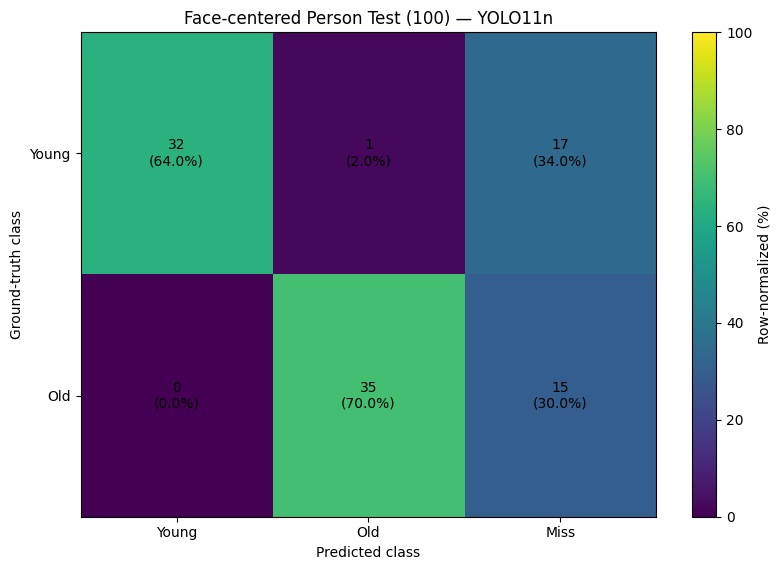

Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/confusion_matrix_troubleshooting/01_face_centered_YOLO11n_confusion.png


Pred_Class,young,old,miss
GT_Class,,,
young,48,2,0
old,0,49,1


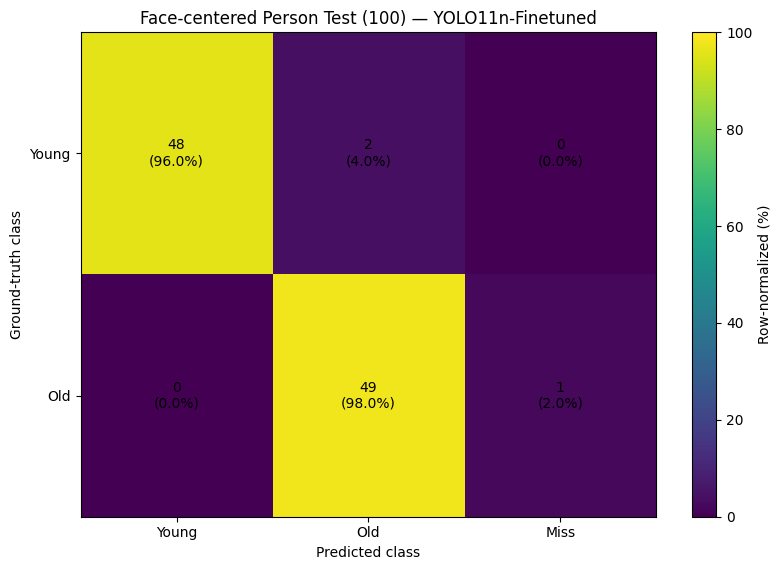

Saved: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/confusion_matrix_troubleshooting/02_face_centered_Finetuned_confusion.png


In [ ]:
# 얼굴 중심 Person 100장 Confusion Matrix

FACE_GT_ORDER = [
    "young",
    "old",
]

face_pred_union = set(
    face_centered_df[
        face_centered_df["Model"].astype(str).isin(
            [BASE_MODEL, FT_MODEL]
        )
    ]["Pred_Class"]
    .astype(str)
    .unique()
    .tolist()
)

FACE_PRED_ORDER = [
    c
    for c in [
        "young",
        "old",
        "animal",
        "miss",
    ]
    if (
        c in face_pred_union
        or c in {"young", "old", "miss"}
    )
]

face_cm_tables = {}

for model_name in [
    BASE_MODEL,
    FT_MODEL,
]:
    g = (
        face_centered_df[
            face_centered_df["Model"].astype(str)
            == model_name
        ]
        .copy()
    )

    table = make_confusion_table(
        g,
        gt_order=FACE_GT_ORDER,
        pred_order=FACE_PRED_ORDER,
    )

    face_cm_tables[model_name] = table

    display(table)

    filename = (
        "01_face_centered_YOLO11n_confusion.png"
        if model_name == BASE_MODEL
        else "02_face_centered_Finetuned_confusion.png"
    )

    plot_confusion_table(
        table,
        title=(
            f"Face-centered Person Test (100) — {model_name}"
        ),
        save_path=CM_ROOT / filename,
    )

## 24-4. 얼굴 중심 이미지에서 Young 오류를 세부 분해

In [ ]:
# 얼굴 중심 Young FN Breakdown

def young_breakdown(
    df,
    model_name,
    scope_name,
):
    g = (
        df[
            df["Model"].astype(str)
            == model_name
        ]
        .copy()
    )

    y = g[
        g["GT_Class"] == "young"
    ].copy()

    support = len(y)

    pred_counts = (
        y["Pred_Class"]
        .astype(str)
        .value_counts()
    )

    tp = int(
        pred_counts.get(
            "young",
            0,
        )
    )

    to_old = int(
        pred_counts.get(
            "old",
            0,
        )
    )

    to_animal = int(
        pred_counts.get(
            "animal",
            0,
        )
    )

    to_miss = int(
        pred_counts.get(
            "miss",
            0,
        )
    )

    detected = int(
        y["Person_Detected"]
        .fillna(False)
        .astype(bool)
        .sum()
    )

    return {
        "Scope": scope_name,
        "Model": model_name,
        "Young_Support": support,
        "Young_TP": tp,
        "Young_to_Old": to_old,
        "Young_to_Animal": to_animal,
        "Young_to_Miss": to_miss,
        "Young_Recall": (
            tp / support
            if support
            else np.nan
        ),
        "Young_Person_Detected": detected,
        "Young_Person_Detection_Rate": (
            detected / support
            if support
            else np.nan
        ),
    }


face_young_breakdown_df = pd.DataFrame([
    young_breakdown(
        face_centered_df,
        BASE_MODEL,
        "Face-centered Person 100",
    ),
    young_breakdown(
        face_centered_df,
        FT_MODEL,
        "Face-centered Person 100",
    ),
])

face_young_breakdown_df.to_csv(
    CM_ROOT / "face_centered_young_breakdown.csv",
    index=False,
    encoding="utf-8-sig",
)

display_df = face_young_breakdown_df.copy()

for col in [
    "Young_Recall",
    "Young_Person_Detection_Rate",
]:
    display_df[col] = (
        display_df[col] * 100.0
    ).round(2)

display(display_df)

base_row = (
    face_young_breakdown_df
    .set_index("Model")
    .loc[BASE_MODEL]
)

ft_row = (
    face_young_breakdown_df
    .set_index("Model")
    .loc[FT_MODEL]
)

print(
    "Face-centered Young Recall delta:",
    f"{(ft_row['Young_Recall'] - base_row['Young_Recall']) * 100:+.2f}%p"
)

print(
    "Face-centered Young Person Detection Rate delta:",
    f"{(ft_row['Young_Person_Detection_Rate'] - base_row['Young_Person_Detection_Rate']) * 100:+.2f}%p"
)

print(
    "Young → Miss delta:",
    int(ft_row["Young_to_Miss"] - base_row["Young_to_Miss"]),
    "samples"
)

,Scope,Model,Young_Support,Young_TP,Young_to_Old,Young_to_Animal,Young_to_Miss,Young_Recall,Young_Person_Detected,Young_Person_Detection_Rate
0,Face-centered Person 100,YOLO11n,50,32,1,0,17,64.0,33,66.0
1,Face-centered Person 100,YOLO11n-Finetuned,50,48,2,0,0,96.0,50,100.0


Face-centered Young Recall delta: +32.00%p
Face-centered Young Person Detection Rate delta: +34.00%p
Young → Miss delta: -17 samples


## 24-5. 전체 211장 Confusion Matrix — Before / After

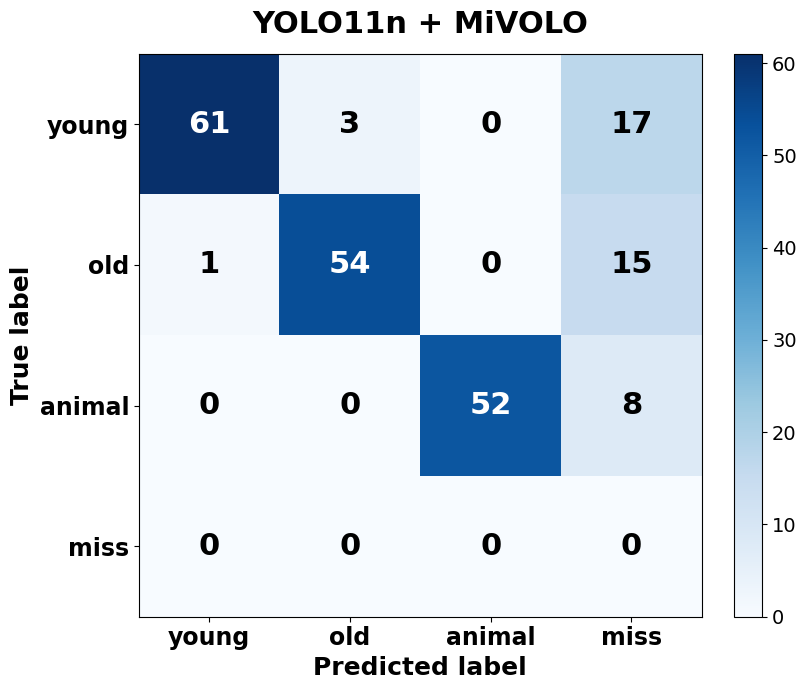

YOLO11n
young    Recall : 61/81 = 75.31%
old      Recall : 54/70 = 77.14%
animal   Recall : 52/60 = 86.67%



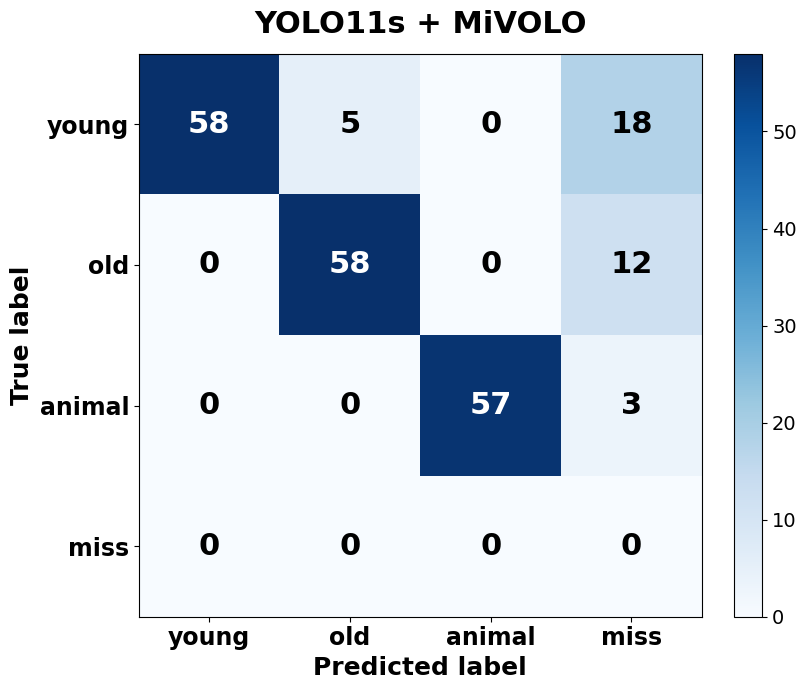

YOLO11s
young    Recall : 58/81 = 71.60%
old      Recall : 58/70 = 82.86%
animal   Recall : 57/60 = 95.00%



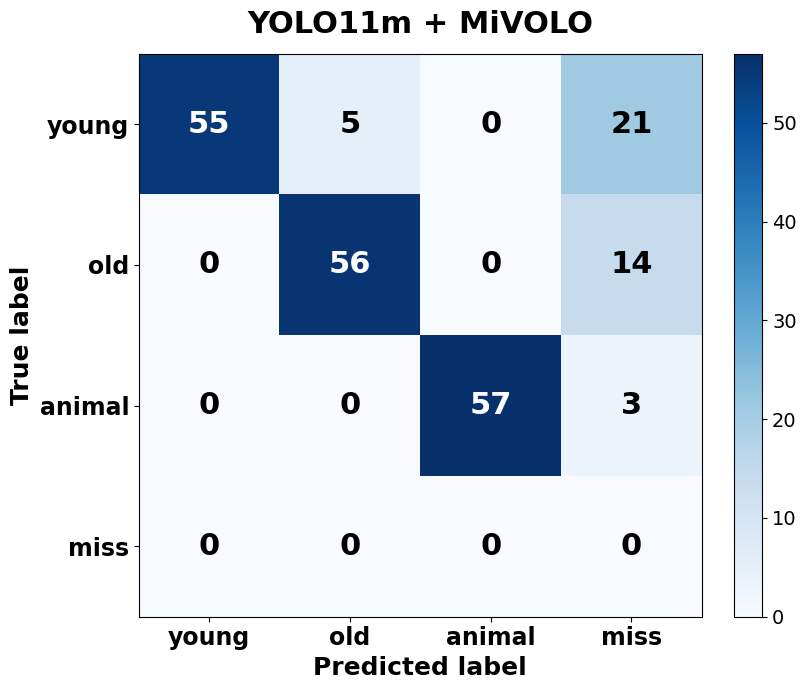

YOLO11m
young    Recall : 55/81 = 67.90%
old      Recall : 56/70 = 80.00%
animal   Recall : 57/60 = 95.00%



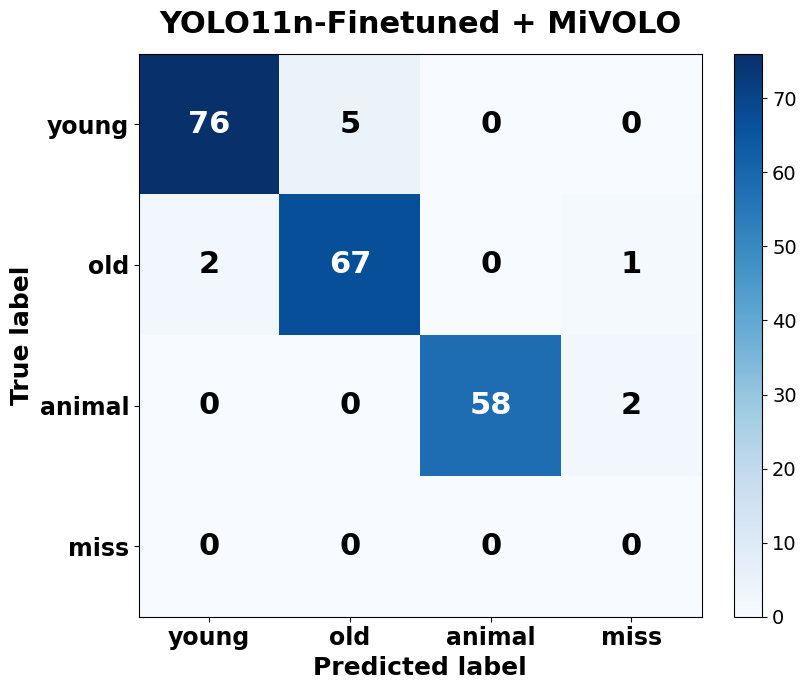

YOLO11n-Finetuned
young    Recall : 76/81 = 93.83%
old      Recall : 67/70 = 95.71%
animal   Recall : 58/60 = 96.67%



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


# 설정

MODELS = [
    "YOLO11n",
    "YOLO11s",
    "YOLO11m",
    "YOLO11n-Finetuned",
]

LABELS = [
    "young",
    "old",
    "animal",
    "miss",
]

# 전체 211장
DATASET_FILTER = None

# 얼굴 중심 Person 100장만 보고 싶으면
# DATASET_FILTER = "UTK"


# Confusion Matrix

def plot_confusion(df, model_name):

    g = df[
        df["Model"].astype(str) == model_name
    ].copy()

    if DATASET_FILTER is not None:
        g = g[
            g["Dataset"].astype(str) == DATASET_FILTER
        ].copy()

    if len(g) == 0:
        print(f"[ERROR] {model_name}: 데이터 없음")
        return

    cm = confusion_matrix(
        g["GT_Class"].astype(str),
        g["Pred_Class"].astype(str),
        labels=LABELS,
    )

    # Plot

    fig, ax = plt.subplots(figsize=(9, 7))

    im = ax.imshow(
        cm,
        cmap="Blues"
    )

    ax.set_xticks(
        np.arange(len(LABELS))
    )

    ax.set_yticks(
        np.arange(len(LABELS))
    )

    ax.set_xticklabels(
        LABELS,
        fontsize=17,
        fontweight="bold"
    )

    ax.set_yticklabels(
        LABELS,
        fontsize=17,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Predicted label",
        fontsize=18,
        fontweight="bold"
    )

    ax.set_ylabel(
        "True label",
        fontsize=18,
        fontweight="bold"
    )

    ax.set_title(
        f"{model_name} + MiVOLO",
        fontsize=22,
        fontweight="bold",
        pad=15
    )

    # 각 칸 숫자

    threshold = (
        cm.max() / 2
        if cm.max() > 0
        else 0
    )

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            value = cm[i, j]

            color = (
                "white"
                if value > threshold
                else "black"
            )

            ax.text(
                j,
                i,
                str(value),
                ha="center",
                va="center",
                fontsize=22,
                fontweight="bold",
                color=color
            )

    # Colorbar

    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    cbar.ax.tick_params(
        labelsize=14
    )

    plt.tight_layout()
    plt.show()

    # Recall 출력

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    for i, label in enumerate(LABELS):

        total = cm[i, :].sum()

        if total == 0:
            continue

        tp = cm[i, i]

        recall = (
            tp / total * 100
        )

        print(
            f"{label:8s} Recall : "
            f"{tp}/{total} = "
            f"{recall:.2f}%"
        )

    print()


# 4개 모델 실행

for model_name in MODELS:

    plot_confusion(
        combined_pred_df,
        model_name
    )

## 24-6. 전체 211장 Young Recall 및 오류 변화 요약

In [ ]:
# 전체 211장 Young FN Breakdown

total_young_breakdown_df = pd.DataFrame([
    young_breakdown(
        total_211_df,
        BASE_MODEL,
        "Combined Test 211",
    ),
    young_breakdown(
        total_211_df,
        FT_MODEL,
        "Combined Test 211",
    ),
])

total_young_breakdown_df.to_csv(
    CM_ROOT / "total211_young_breakdown.csv",
    index=False,
    encoding="utf-8-sig",
)

display_df = total_young_breakdown_df.copy()

for col in [
    "Young_Recall",
    "Young_Person_Detection_Rate",
]:
    display_df[col] = (
        display_df[col] * 100.0
    ).round(2)

display(display_df)

base_total = (
    total_young_breakdown_df
    .set_index("Model")
    .loc[BASE_MODEL]
)

ft_total = (
    total_young_breakdown_df
    .set_index("Model")
    .loc[FT_MODEL]
)

print(
    "Combined Young Recall:",
    f"{base_total['Young_Recall'] * 100:.1f}%"
    " → "
    f"{ft_total['Young_Recall'] * 100:.1f}%"
)

print(
    "Delta:",
    f"{(ft_total['Young_Recall'] - base_total['Young_Recall']) * 100:+.1f}%p"
)

,Scope,Model,Young_Support,Young_TP,Young_to_Old,Young_to_Animal,Young_to_Miss,Young_Recall,Young_Person_Detected,Young_Person_Detection_Rate
0,Combined Test 211,YOLO11n,81,61,3,0,17,75.31,64,79.01
1,Combined Test 211,YOLO11n-Finetuned,81,76,5,0,0,93.83,81,100.00


Combined Young Recall: 75.3% → 93.8%
Delta: +18.5%p


## 24-7. 최종 결과 정리


In [ ]:
b = (
    face_young_breakdown_df
    .set_index("Model")
    .loc[BASE_MODEL]
)

f = (
    face_young_breakdown_df
    .set_index("Model")
    .loc[FT_MODEL]
)

recall_delta = (
    f["Young_Recall"]
    - b["Young_Recall"]
) * 100.0

det_delta = (
    f["Young_Person_Detection_Rate"]
    - b["Young_Person_Detection_Rate"]
) * 100.0

miss_delta = int(
    f["Young_to_Miss"]
    - b["Young_to_Miss"]
)

print("=" * 70)
print("PPT 해석")
print("=" * 70)

print(
    f"얼굴 중심 Person 이미지에서 Young Recall은 "
    f"{b['Young_Recall'] * 100:.1f}% → "
    f"{f['Young_Recall'] * 100:.1f}% "
    f"({recall_delta:+.1f}%p) 변화함."
)

print(
    f"Young 대상의 Person Detection Rate는 "
    f"{b['Young_Person_Detection_Rate'] * 100:.1f}% → "
    f"{f['Young_Person_Detection_Rate'] * 100:.1f}% "
    f"({det_delta:+.1f}%p) 변화함."
)

print(
    f"Young → Miss는 "
    f"{int(b['Young_to_Miss'])}건 → "
    f"{int(f['Young_to_Miss'])}건 "
    f"({miss_delta:+d}건) 변화함."
)

print()

if (
    det_delta > 0
    and miss_delta < 0
):
    print(
        "[해석] 얼굴 중심 Young 이미지에서 Person 검출률이 증가하고 "
        "Miss가 감소하는 경향이 확인됨."
    )
    print(
        "→ 얼굴 중심 Person 데이터를 포함한 Fine-tuning 이후 "
        "Young 미검출 감소와 함께 전체 Young Recall이 향상됨."
    )
else:
    print(
        "[주의] Young Recall 변화가 Person Detection 개선만으로 "
        "설명되지는 않습니다."
    )
    print(
        "→ Confusion Matrix의 Young→Old / Young→Miss 변화를 함께 "
        "설명하는 것이 정확합니다."
    )

print()
print(
    "※ 얼굴 중심 Person 데이터 외 다른 Fine-tuning 데이터도 함께 사용했으므로, "
    "향상 원인을 얼굴 데이터 하나로 단정하지 않습니다."
)

PPT 해석
얼굴 중심 Person 이미지에서 Young Recall은 64.0% → 96.0% (+32.0%p) 변화함.
Young 대상의 Person Detection Rate는 66.0% → 100.0% (+34.0%p) 변화함.
Young → Miss는 17건 → 0건 (-17건) 변화함.

[해석] 얼굴 중심 Young 이미지에서 Person 검출률이 증가하고 Miss가 감소하는 경향이 확인됨.
→ 얼굴 중심 Person 데이터를 포함한 Fine-tuning 이후 Young 미검출 감소와 함께 전체 Young Recall이 향상됨.

※ 얼굴 중심 Person 데이터 외 다른 Fine-tuning 데이터도 함께 사용했으므로, 향상 원인을 얼굴 데이터 하나로 단정하지 않습니다.


## 24-8. 결과 파일 ZIP 저장

In [ ]:
# Confusion Matrix 결과 ZIP

ZIP_PATH = (
    RESULT_ROOT
    / "ConfusionMatrix_Troubleshooting_Results.zip"
)

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

shutil.make_archive(
    str(ZIP_PATH.with_suffix("")),
    "zip",
    root_dir=CM_ROOT,
)

print("Saved ZIP:", ZIP_PATH)
print("\nGenerated files:")

for p in sorted(CM_ROOT.iterdir()):
    print(" -", p.name)

Saved ZIP: /content/drive/MyDrive/yolo11n_safe_finetune_utk100/colab_eval_results/ConfusionMatrix_Troubleshooting_Results.zip

Generated files:
 - 01_face_centered_YOLO11n_confusion.png
 - 02_face_centered_Finetuned_confusion.png
 - 03_total211_YOLO11n_confusion.png
 - 04_total211_Finetuned_confusion.png
 - face_centered_young_breakdown.csv
 - total211_young_breakdown.csv


## 추가 n / s / m / Fine-tuned 비교 그래프

,Final_Accuracy,Young_Recall,Animal_Recall
Model,,,
YOLO11n,0.791469,0.753086,0.866667
YOLO11s,0.819905,0.716049,0.950000
YOLO11m,0.796209,0.679012,0.950000
YOLO11n-Finetuned,0.962085,0.938272,0.983333


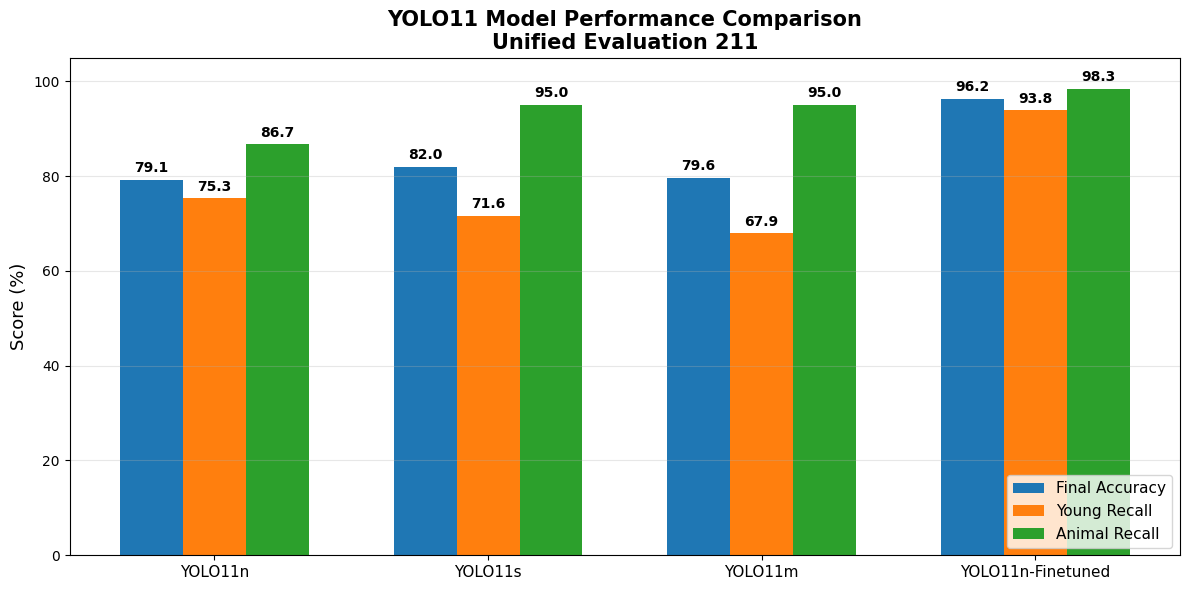

In [ ]:
# YOLO11n / s / m / Fine-tuned
# Unified211 실제 계산 결과 비교
# Final Accuracy / Young Recall / Animal Recall

import numpy as np
import matplotlib.pyplot as plt

MODEL_ORDER = [
    "YOLO11n",
    "YOLO11s",
    "YOLO11m",
    "YOLO11n-Finetuned",
]

# Unified211에서 실제 계산된 결과 사용

plot_df = (
    combined_summary_df
    .set_index("Model")
    .reindex(MODEL_ORDER)
)

# 값이 정상적으로 존재하는지 확인
display(
    plot_df[
        [
            "Final_Accuracy",
            "Young_Recall",
            "Animal_Recall",
        ]
    ]
)

# 그래프에 사용할 실제 계산값

final_accuracy = (
    plot_df["Final_Accuracy"]
    .to_numpy()
    * 100
)

young_recall = (
    plot_df["Young_Recall"]
    .to_numpy()
    * 100
)

animal_recall = (
    plot_df["Animal_Recall"]
    .to_numpy()
    * 100
)

x = np.arange(len(MODEL_ORDER))
width = 0.23

fig, ax = plt.subplots(
    figsize=(12, 6)
)

bars1 = ax.bar(
    x - width,
    final_accuracy,
    width,
    label="Final Accuracy",
)

bars2 = ax.bar(
    x,
    young_recall,
    width,
    label="Young Recall",
)

bars3 = ax.bar(
    x + width,
    animal_recall,
    width,
    label="Animal Recall",
)

def add_value_labels(bars):
    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            height + 1.0,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )


add_value_labels(bars1)
add_value_labels(bars2)
add_value_labels(bars3)

ax.set_title(
    "YOLO11 Model Performance Comparison\n"
    "Unified Evaluation 211",
    fontsize=15,
    fontweight="bold",
)

ax.set_ylabel(
    "Score (%)",
    fontsize=13,
)

ax.set_xticks(x)

ax.set_xticklabels(
    MODEL_ORDER,
    fontsize=11,
)

ax.set_ylim(
    0,
    105,
)

ax.legend(
    fontsize=11,
    loc="lower right",
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

plt.savefig(
    "YOLO11_nsm_finetuned_Unified211.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()